#   HR Employee Attrition Analysis
## *Understanding Why Employees Leave — and What It's Costing the Business*

---
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Tool:** Python (Jupyter Notebook)  

---

> *"The cost of replacing an employee is rarely visible on a P&L statement —  
> but it shows up everywhere else: in lost productivity, in failed projects,  
> and in the institutional knowledge that walks out the door."*

---

---
## Chapter 1 — Defining the Business Problem

### Why This Analysis Exists

Every year, organizations lose millions of dollars not to failed products or bad strategy —
but to **employee attrition**: the quiet, continuous drain of talent leaving faster
than it can be replaced.

The instinct is to treat attrition as an HR metric. This analysis treats it as a **financial risk**.

Before writing a single line of analytical code, we answer the question a CFO would ask:

> **"What is employee attrition actually costing this organization — and where is that cost concentrated?"**

---

### The Real Cost of Losing an Employee

Replacing an employee is expensive in ways that rarely appear in a single budget line:

| Cost Category | What It Includes |
|---|---|
| **Recruitment** | Job posting, agency fees, interviewer time |
| **Onboarding** | Training programs, productivity ramp-up period |
| **Lost productivity** | 6–12 months before a new hire reaches full output |
| **Institutional knowledge** | Relationships, processes, and context that leave with the person |
| **Team disruption** | Morale impact and workload redistribution on remaining employees |

Industry research (SHRM, Gallup, Deloitte) estimates replacement costs at
**50% to 200% of annual salary**. We use **100%** as our conservative baseline.

---

In [3]:
# =============================================================================
# CHAPTER 1 | Business Problem Definition & Cost Modeling
# =============================================================================
# Purpose  : Translate the attrition problem into financial terms.
#            Every subsequent chapter traces back to the cost model built here.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global visual style ───────────────────────────────────────────────────────
# Defined once here — every chart in every chapter inherits this style.

plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.spines.bottom': True,
    'axes.grid'         : True,
    'axes.grid.axis'    : 'y',
    'grid.color'        : '#E5E5E5',
    'grid.linewidth'    : 0.8,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 15,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.frameon'    : False,
    'legend.fontsize'   : 10,
})

# ── Project-wide color palette ────────────────────────────────────────────────
# Used consistently across all chapters.
# Red = attrition/risk | Teal = retained/stable | Amber = emphasis/callout

COLORS = {
    'attrition' : '#E05252',
    'retained'  : '#2A9D8F',
    'neutral'   : '#6C757D',
    'highlight' : '#F4A261',
    'dark'      : '#264653',
    'light_bg'  : '#F8F9FA',
}

print(" Libraries loaded. Global style and color palette set.")

 Libraries loaded. Global style and color palette set.


In [4]:
# =============================================================================
# Load the raw dataset and perform an immediate sanity check.
# We keep df_raw untouched throughout the project as a reference copy.
# All modifications happen on df.
# =============================================================================

df_raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df     = df_raw.copy()

print("=" * 55)
print(f"  Rows              : {df.shape[0]:,}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Employees who left: {(df['Attrition']=='Yes').sum()}")
print(f"  Attrition Rate    : {(df['Attrition']=='Yes').mean():.1%}")
print("=" * 55)

  Rows              : 1,470
  Columns           : 35
  Missing Values    : 0
  Employees who left: 237
  Attrition Rate    : 16.1%


In [5]:
# =============================================================================
# THE COST MODEL — translating headcount loss into financial impact
#
# Formula: Replacement Cost = Employees Lost × Avg Annual Salary × Rate
# Three scenarios: Conservative (50%), Moderate (100%), Aggressive (200%)
# We present all three so readers can apply their own assumptions.
# =============================================================================

# ── Core metrics ──────────────────────────────────────────────────────────────
total_employees   = len(df)
total_attrited    = (df['Attrition'] == 'Yes').sum()
attrition_rate    = total_attrited / total_employees
avg_annual_salary = df['MonthlyIncome'].mean() * 12
median_annual_sal = df['MonthlyIncome'].median() * 12

# ── Cost per exit ─────────────────────────────────────────────────────────────
cost_conservative = avg_annual_salary * 0.50
cost_moderate     = avg_annual_salary * 1.00   # our primary estimate
cost_aggressive   = avg_annual_salary * 2.00

# ── Total annual attrition cost ───────────────────────────────────────────────
total_cost_cons   = cost_conservative * total_attrited
total_cost_mod    = cost_moderate     * total_attrited
total_cost_agg    = cost_aggressive   * total_attrited

# ── Savings potential ─────────────────────────────────────────────────────────
savings_25pct     = total_cost_mod * 0.25
savings_50pct     = total_cost_mod * 0.50

# ── Institutional knowledge lost ─────────────────────────────────────────────
avg_tenure_left   = df[df['Attrition']=='Yes']['YearsAtCompany'].mean()
avg_tenure_stayed = df[df['Attrition']=='No']['YearsAtCompany'].mean()
total_years_lost  = df[df['Attrition']=='Yes']['YearsAtCompany'].sum()

# ── Executive summary print ───────────────────────────────────────────────────
print("=" * 58)
print("   ANNUAL ATTRITION COST MODEL — EXECUTIVE SUMMARY")
print("=" * 58)
print(f"\n  Workforce Size          : {total_employees:,}")
print(f"  Employees Who Left      : {total_attrited:,} ({attrition_rate:.1%})")
print(f"  Avg Annual Salary       : ${avg_annual_salary:>10,.0f}")
print(f"  Median Annual Salary    : ${median_annual_sal:>10,.0f}")
print()
print("  ── Cost Per Exit ──")
print(f"  Conservative (50%)      : ${cost_conservative:>10,.0f}")
print(f"  Moderate     (100%) ←   : ${cost_moderate:>10,.0f}  ← our baseline")
print(f"  Aggressive   (200%)     : ${cost_aggressive:>10,.0f}")
print()
print("  ── Total Annual Cost ──")
print(f"  Conservative            : ${total_cost_cons:>12,.0f}")
print(f"  Moderate                : ${total_cost_mod:>12,.0f}")
print(f"  Aggressive              : ${total_cost_agg:>12,.0f}")
print()
print("  ── Savings Potential (moderate baseline) ──")
print(f"  Reduce attrition 25%    : ${savings_25pct:>12,.0f} saved/year")
print(f"  Reduce attrition 50%    : ${savings_50pct:>12,.0f} saved/year")
print()
print("  ── Knowledge Loss ──")
print(f"  Avg tenure — left       : {avg_tenure_left:.1f} years")
print(f"  Avg tenure — stayed     : {avg_tenure_stayed:.1f} years")
print(f"  Total experience lost   : {total_years_lost:,} years")
print("=" * 58)

   ANNUAL ATTRITION COST MODEL — EXECUTIVE SUMMARY

  Workforce Size          : 1,470
  Employees Who Left      : 237 (16.1%)
  Avg Annual Salary       : $    78,035
  Median Annual Salary    : $    59,028

  ── Cost Per Exit ──
  Conservative (50%)      : $    39,018
  Moderate     (100%) ←   : $    78,035  ← our baseline
  Aggressive   (200%)     : $   156,070

  ── Total Annual Cost ──
  Conservative            : $   9,247,168
  Moderate                : $  18,494,337
  Aggressive              : $  36,988,673

  ── Savings Potential (moderate baseline) ──
  Reduce attrition 25%    : $   4,623,584 saved/year
  Reduce attrition 50%    : $   9,247,168 saved/year

  ── Knowledge Loss ──
  Avg tenure — left       : 5.1 years
  Avg tenure — stayed     : 7.4 years
  Total experience lost   : 1,216 years


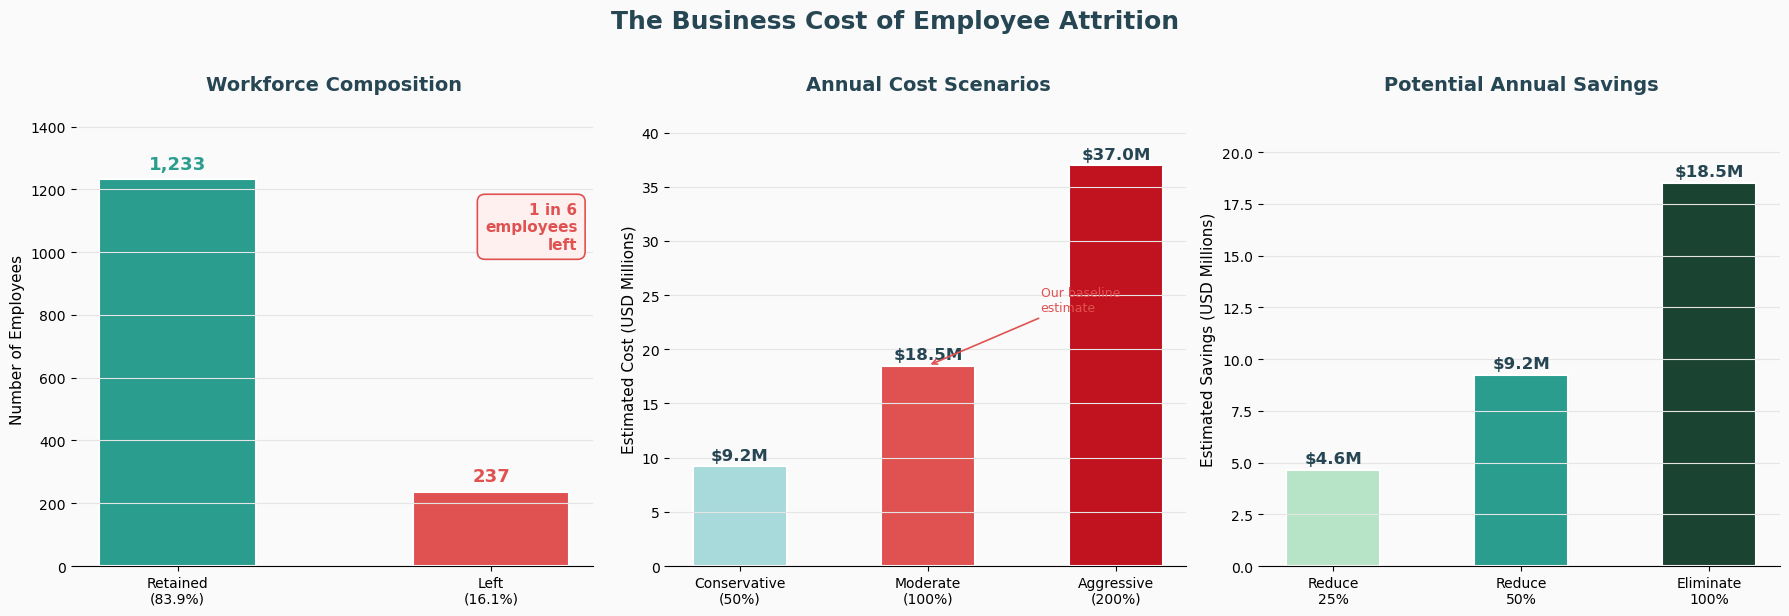

In [6]:
# =============================================================================
# VISUALIZATION | 3-panel cost dashboard
# Panel 1: Workforce composition  |  Panel 2: Cost scenarios
# Panel 3: Savings potential
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('The Business Cost of Employee Attrition',
             fontsize=18, fontweight='bold', color=COLORS['dark'], y=1.02)

# ── Panel 1: Workforce Composition ───────────────────────────────────────────
ax1   = axes[0]
sizes = [(df['Attrition']=='No').sum(), (df['Attrition']=='Yes').sum()]
bars  = ax1.bar(['Retained\n(83.9%)', 'Left\n(16.1%)'], sizes,
                color=[COLORS['retained'], COLORS['attrition']],
                width=0.5, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, sizes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{count:,}', ha='center', va='bottom',
             fontsize=13, fontweight='bold', color=bar.get_facecolor())

ax1.set_title('Workforce Composition', fontweight='bold', color=COLORS['dark'])
ax1.set_ylabel('Number of Employees')
ax1.set_ylim(0, 1450)
ax1.text(0.97, 0.80, '1 in 6\nemployees\nleft',
         transform=ax1.transAxes, ha='right', va='top', fontsize=11,
         color=COLORS['attrition'], fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF0F0',
                   edgecolor=COLORS['attrition'], linewidth=1.2))

# ── Panel 2: Cost Scenarios ───────────────────────────────────────────────────
ax2   = axes[1]
costs = [total_cost_cons/1e6, total_cost_mod/1e6, total_cost_agg/1e6]
bars2 = ax2.bar(['Conservative\n(50%)', 'Moderate\n(100%)', 'Aggressive\n(200%)'],
                costs, color=['#A8DADC', COLORS['attrition'], '#C1121F'],
                width=0.5, edgecolor='white', linewidth=1.5)

for bar, cost in zip(bars2, costs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${cost:.1f}M', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color=COLORS['dark'])

ax2.set_title('Annual Cost Scenarios', fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Estimated Cost (USD Millions)')
ax2.set_ylim(0, 42)
ax2.annotate('Our baseline\nestimate',
             xy=(1, total_cost_mod/1e6), xytext=(1.6, total_cost_mod/1e6 + 5),
             fontsize=9, color=COLORS['attrition'],
             arrowprops=dict(arrowstyle='->', color=COLORS['attrition'], lw=1.2))

# ── Panel 3: Savings Potential ────────────────────────────────────────────────
ax3      = axes[2]
sav_vals = [savings_25pct/1e6, savings_50pct/1e6, total_cost_mod/1e6]
bars3    = ax3.bar(['Reduce\n25%', 'Reduce\n50%', 'Eliminate\n100%'],
                   sav_vals, color=['#B7E4C7', COLORS['retained'], '#1B4332'],
                   width=0.5, edgecolor='white', linewidth=1.5)

for bar, saving in zip(bars3, sav_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'${saving:.1f}M', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color=COLORS['dark'])

ax3.set_title('Potential Annual Savings', fontweight='bold', color=COLORS['dark'])
ax3.set_ylabel('Estimated Savings (USD Millions)')
ax3.set_ylim(0, 22)

plt.tight_layout()
plt.savefig('chapter1_cost_model.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

  ATTRITION COST BY DEPARTMENT
Department                    Left    Rate   Avg Salary    Est. Cost
--------------------------------------------------------------------
  Research & Development       133   13.8%$      75,375$  10,024,880
  Sales                         92   20.6%$      83,510$   7,682,927
  Human Resources               12   19.0%$      79,854$     958,249
--------------------------------------------------------------------
  TOTAL                        237              $  18,666,055


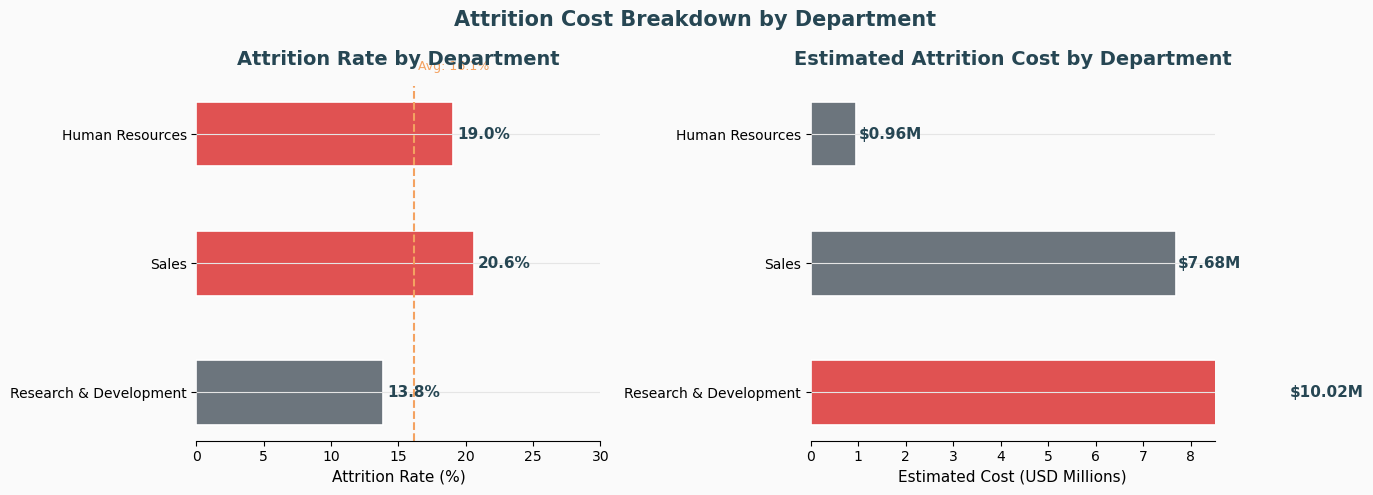

In [7]:
# =============================================================================
# DEPARTMENT COST BREAKDOWN
# Which departments are driving the $18.5M cost figure?
# Cost = employees lost × dept avg annual salary × 100% replacement rate
# =============================================================================

dept_stats = df.groupby('Department').agg(
    total   = ('Attrition', 'count'),
    left    = ('Attrition', lambda x: (x=='Yes').sum()),
    avg_sal = ('MonthlyIncome', lambda x: x.mean() * 12)
).reset_index()

dept_stats['rate'] = dept_stats['left'] / dept_stats['total']
dept_stats['cost'] = dept_stats['left'] * dept_stats['avg_sal']
dept_stats         = dept_stats.sort_values('cost', ascending=False)

print("=" * 68)
print("  ATTRITION COST BY DEPARTMENT")
print("=" * 68)
print(f"{'Department':<28}{'Left':>6}{'Rate':>8}{'Avg Salary':>13}{'Est. Cost':>13}")
print("-" * 68)
for _, r in dept_stats.iterrows():
    print(f"  {r['Department']:<26}{int(r['left']):>6}"
          f"{r['rate']:>8.1%}${r['avg_sal']:>12,.0f}${r['cost']:>12,.0f}")
print("-" * 68)
print(f"  {'TOTAL':<26}{dept_stats['left'].sum():>6}"
      f"              ${dept_stats['cost'].sum():>12,.0f}")
print("=" * 68)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Attrition Cost Breakdown by Department',
             fontsize=15, fontweight='bold', color=COLORS['dark'])

# Attrition rate
ax1       = axes[0]
d_colors  = [COLORS['attrition'] if r > attrition_rate else COLORS['neutral']
             for r in dept_stats['rate']]
bars      = ax1.barh(dept_stats['Department'], dept_stats['rate']*100,
                     color=d_colors, edgecolor='white', linewidth=1.2, height=0.5)
ax1.axvline(attrition_rate*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5)
ax1.text(attrition_rate*100 + 0.3, 2.5, f'Avg: {attrition_rate:.1%}',
         color=COLORS['highlight'], fontsize=9)
for bar, r in zip(bars, dept_stats['rate']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{r:.1%}', va='center', fontsize=11,
             fontweight='bold', color=COLORS['dark'])
ax1.set_xlabel('Attrition Rate (%)')
ax1.set_title('Attrition Rate by Department', fontweight='bold', color=COLORS['dark'])
ax1.set_xlim(0, 30)

# Cost
ax2      = axes[1]
c_colors = [COLORS['attrition'] if c == dept_stats['cost'].max()
            else COLORS['neutral'] for c in dept_stats['cost']]
bars2    = ax2.barh(dept_stats['Department'], dept_stats['cost']/1e6,
                    color=c_colors, edgecolor='white', linewidth=1.2, height=0.5)
for bar, cost in zip(bars2, dept_stats['cost']):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'${cost/1e6:.2f}M', va='center', fontsize=11,
             fontweight='bold', color=COLORS['dark'])
ax2.set_xlabel('Estimated Cost (USD Millions)')
ax2.set_title('Estimated Attrition Cost by Department', fontweight='bold', color=COLORS['dark'])
ax2.set_xlim(0, 8.5)

plt.tight_layout()
plt.savefig('chapter1_dept_cost.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

---
## Chapter 1 — Key Findings

| Metric | Value |
|---|---|
| Attrition rate | **16.1%** — above the 10–12% industry benchmark |
| Employees who left | **237** out of 1,470 |
| Estimated annual cost (moderate) | **~$18.5 million** |
| Savings if attrition reduced 25% | **~$4.6 million/year** |
| Avg institutional knowledge lost | **5.1 years per exit** |
| Highest cost departments | **R&D and Sales — ~$6.5M each** |

> **Note on the $6.5M figure:** This is an estimate calculated as
> *employees who left × department average annual salary × 100% replacement rate*.
> Actual costs vary by seniority and role complexity. This is a conservative floor, not a ceiling.

**The question this raises:** The cost figure tells us the *scale*.
It doesn't tell us the *cause*.
That is what Chapters 3 through 6 will systematically uncover.

---

> **Next → Chapter 2: Data Audit & Cleaning**

---

---
## Chapter 2 — Data Audit & Cleaning

Before drawing any conclusion, a responsible analyst must answer:
- **What does each column actually mean?** Not just its name, but its business interpretation.
- **Is the data trustworthy?** Missing values, impossible values, zero-variance columns.
- **What needs to change?** Encoding, binning, dropping, or engineering new features.

This chapter documents every decision made on the dataset's 35 columns — with the *reason*
behind each one. In a real business setting, these decisions would be reviewed with the HR team
before analysis begins.

> A model built on poorly understood data produces confidently wrong answers.

---

In [10]:
# =============================================================================
# CHAPTER 2 | Data Audit & Cleaning
# =============================================================================
# Purpose: Document every column — what it is, what we do with it, and why.
#          This is the data dictionary for the entire project.
# =============================================================================
# NOTE: We continue using df loaded in Chapter 1.
#       df_raw is still available as our untouched reference copy.
# =============================================================================

audit_data = {
    'Column': [
        'EmployeeCount','Over18','StandardHours',
        'EmployeeNumber',
        'DailyRate','HourlyRate','MonthlyRate',
        'Age','Department','DistanceFromHome',
        'EducationField','Gender','JobRole',
        'MaritalStatus','MonthlyIncome',
        'NumCompaniesWorked','OverTime',
        'PercentSalaryHike','StockOptionLevel',
        'TotalWorkingYears','TrainingTimesLastYear',
        'YearsAtCompany','YearsInCurrentRole',
        'YearsSinceLastPromotion','YearsWithCurrManager',
        'BusinessTravel','Education',
        'EnvironmentSatisfaction','JobInvolvement',
        'JobLevel','JobSatisfaction',
        'PerformanceRating','RelationshipSatisfaction',
        'WorkLifeBalance','Attrition'
    ],
    'Action': [
        'DROP','DROP','DROP',
        'DROP',
        'DROP','DROP','DROP',
        'KEEP','KEEP','KEEP',
        'KEEP','KEEP','KEEP',
        'KEEP','KEEP',
        'KEEP','ENCODE',
        'KEEP','KEEP',
        'KEEP','KEEP',
        'KEEP','KEEP',
        'KEEP','KEEP',
        'ENCODE','KEEP',
        'KEEP','KEEP',
        'KEEP','KEEP',
        'FLAG','KEEP',
        'KEEP','ENCODE'
    ],
    'Reason': [
        'Zero variance — value is always 1',
        'Zero variance — every employee is over 18',
        'Zero variance — always 80 hours',
        'Row identifier only — not a behavioral feature',
        'Correlation with attrition < 0.05 — MonthlyIncome is the real compensation signal',
        'Correlation with attrition < 0.05 — MonthlyIncome is the real compensation signal',
        'Correlation with attrition < 0.05 — MonthlyIncome is the real compensation signal',
        'Key demographic — kept continuous, also binned into Age_Group',
        'Primary segmentation variable for all interaction analysis',
        'Commute burden proxy — kept continuous, also binned into Commute_Category',
        'Educational background context — kept for role-fit analysis',
        'Demographic variable — relevant for equity and segment analysis',
        'Most granular job-level variable — key for role-level attrition analysis',
        'Strong attrition signal — singles leave at 2.5x rate of divorced',
        'Core compensation variable — used in all salary interaction analyses',
        'Career mobility indicator — high values suggest job-hopping tendency',
        'Binary string — encoded to 1/0 as OverTime_Flag',
        'Recent reward signal — kept as-is',
        'Equity stake proxy — financial attachment to company',
        'Career stage indicator — correlated with Age and JobLevel',
        'Training investment — potential retention lever',
        'Tenure at company — key predictor, also banded into Tenure_Band',
        'Role stability — stagnation vs. growth signal',
        'Time without promotion — dissatisfaction signal when combined with role tenure',
        'Manager relationship stability',
        'Ordered categories — encoded 0/1/2 preserving travel intensity',
        '1–5 ordinal scale — already numeric, kept as-is',
        '1–4 satisfaction scale — kept as ordinal numeric',
        '1–4 involvement scale — kept as ordinal numeric',
        '1–5 seniority scale — kept as ordinal numeric',
        '1–4 satisfaction scale — kept as ordinal numeric',
        'Only 2 values (3 and 4) — near-zero variance, flagged for caution',
        '1–4 satisfaction scale — kept as ordinal numeric',
        '1–4 balance scale — key variable for interaction analysis',
        'Target variable — encoded to 1/0 as Attrition_Flag'
    ]
}

audit_df = pd.DataFrame(audit_data)

for action in ['DROP', 'ENCODE', 'FLAG', 'KEEP']:
    subset = audit_df[audit_df['Action'] == action]
    icons  = {'DROP':'🗑️ ','ENCODE':'🔄','FLAG':'⚠️ ','KEEP':'✅'}
    print(f"\n{icons[action]}  {action} ({len(subset)} columns)")
    print("-" * 72)
    for _, row in subset.iterrows():
        print(f"  {row['Column']:<28} {row['Reason'][:60]}")


🗑️   DROP (7 columns)
------------------------------------------------------------------------
  EmployeeCount                Zero variance — value is always 1
  Over18                       Zero variance — every employee is over 18
  StandardHours                Zero variance — always 80 hours
  EmployeeNumber               Row identifier only — not a behavioral feature
  DailyRate                    Correlation with attrition < 0.05 — MonthlyIncome is the rea
  HourlyRate                   Correlation with attrition < 0.05 — MonthlyIncome is the rea
  MonthlyRate                  Correlation with attrition < 0.05 — MonthlyIncome is the rea

🔄  ENCODE (3 columns)
------------------------------------------------------------------------
  OverTime                     Binary string — encoded to 1/0 as OverTime_Flag
  BusinessTravel               Ordered categories — encoded 0/1/2 preserving travel intensi
  Attrition                    Target variable — encoded to 1/0 as Attrition_Flag


In [11]:
# =============================================================================
# STEP 1 | Drop zero-variance and identifier columns
#
# We verify before dropping — never drop blindly.
# The rate column decision is backed by a correlation test.
# =============================================================================

# ── Verify zero-variance ──────────────────────────────────────────────────────
print("Zero-variance check:")
for col in ['EmployeeCount', 'Over18', 'StandardHours']:
    print(f"  {col}: always = {df[col].unique()[0]}")

# ── Verify rate columns have near-zero attrition signal ──────────────────────
# We test correlation before dropping — this is a decision, not an assumption.
temp_flag = (df['Attrition'] == 'Yes').astype(int)
print("\nCorrelation with attrition (rate cols vs MonthlyIncome):")
for col in ['DailyRate', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome']:
    print(f"  {col:<22}: {df[col].corr(temp_flag):>+.4f}")

# ── Drop confirmed columns ────────────────────────────────────────────────────
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours',
                'EmployeeNumber', 'DailyRate', 'HourlyRate', 'MonthlyRate']

df.drop(columns=cols_to_drop, inplace=True)

print(f"\n Dropped {len(cols_to_drop)} columns.")
print(f"   Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Zero-variance check:
  EmployeeCount: always = 1
  Over18: always = Y
  StandardHours: always = 80

Correlation with attrition (rate cols vs MonthlyIncome):
  DailyRate             : -0.0567
  HourlyRate            : -0.0068
  MonthlyRate           : +0.0152
  MonthlyIncome         : -0.1598

 Dropped 7 columns.
   Dataset shape: 1,470 rows × 28 columns


In [12]:
# =============================================================================
# STEP 2 | Encode categorical variables
#
# Explicit mapping (not get_dummies) so every value is documented.
# Direction is intentional: 1 = more risk / more of the attribute.
# =============================================================================

# ── Target variable ───────────────────────────────────────────────────────────
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# ── OverTime ─────────────────────────────────────────────────────────────────
df['OverTime_Flag'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# ── BusinessTravel — ordered by intensity ────────────────────────────────────
# Non-Travel(0) → Travel_Rarely(1) → Travel_Frequently(2)
df['BusinessTravel_Encoded'] = df['BusinessTravel'].map({
    'Non-Travel'       : 0,
    'Travel_Rarely'    : 1,
    'Travel_Frequently': 2
})

print("Encodings applied:")
print(f"  Attrition_Flag       : Yes→1, No→0")
print(f"  OverTime_Flag        : Yes→1, No→0")
print(f"  BusinessTravel_Encoded: Non-Travel→0, Rarely→1, Frequently→2")

# ── PerformanceRating flag ────────────────────────────────────────────────────
# Only values 3 and 4 exist — no one rated 1 or 2.
# This column will be retained but conclusions drawn from it should be cautious.
perf_counts = df['PerformanceRating'].value_counts()
print(f"\n PerformanceRating has only 2 values: {sorted(df['PerformanceRating'].unique())}")
print(f"   Rating 3: {perf_counts[3]} employees | Rating 4: {perf_counts[4]} employees")
print(f"   Treat findings from this column with caution — near-zero variance.")

print("\n Encoding complete.")

Encodings applied:
  Attrition_Flag       : Yes→1, No→0
  OverTime_Flag        : Yes→1, No→0
  BusinessTravel_Encoded: Non-Travel→0, Rarely→1, Frequently→2

 PerformanceRating has only 2 values: [3, 4]
   Rating 3: 1244 employees | Rating 4: 226 employees
   Treat findings from this column with caution — near-zero variance.

 Encoding complete.


In [13]:
# =============================================================================
# STEP 3 | Feature Engineering
#
# Raw columns are precise but not always analytically useful.
# Engineered features group continuous variables into meaningful segments
# that reflect real career and behavioral patterns.
#
# Every feature here is built from business logic — not just statistical
# convenience. This is what separates domain-aware analysis from generic EDA.
# =============================================================================

# ── 1. Age Group — career stage segments ─────────────────────────────────────
# 18–25 : Early career — high ambition, low switching cost, exploration phase
# 26–35 : Growth phase — salary-sensitive, building career capital
# 36–45 : Mid career  — work-life balance becomes primary concern
# 46+   : Senior phase — stability-seeking, often have dependents

df['Age_Group'] = pd.cut(df['Age'],
                         bins=[17, 25, 35, 45, 60],
                         labels=['18–25', '26–35', '36–45', '46+'])

# ── 2. Income Tier — quartile-based salary segmentation ──────────────────────
# Quartile bands ensure equal population in each tier.
# Avoids assuming salary's effect on attrition is perfectly linear.

df['Income_Tier'] = pd.qcut(df['MonthlyIncome'], q=4,
                             labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

# ── 3. Tenure Band — career phase at this company ────────────────────────────
# 0–2  yrs: Honeymoon phase — high risk if expectations aren't met
# 3–5  yrs: First checkpoint — common "should I stay?" decision point
# 6–10 yrs: Embedded phase — leaving becomes harder (relationships, vesting)
# 11–20 yrs: Long-tenured — leaving is rare but not impossible
# 20+  yrs: Career employees — very low attrition risk

df['Tenure_Band'] = pd.cut(df['YearsAtCompany'],
                           bins=[-1, 2, 5, 10, 20, 40],
                           labels=['0–2 yrs','3–5 yrs','6–10 yrs','11–20 yrs','20+ yrs'])

# ── 4. Stagnation Flag — compound career dissatisfaction signal ───────────────
# An employee is stagnant if they have BOTH:
#   - Been in the same role for 3+ years, AND
#   - Not received a promotion in 3+ years
# Neither condition alone is necessarily a problem.
# Together they suggest a career that has stopped moving.

df['Stagnation_Flag'] = (
    (df['YearsInCurrentRole']      >= 3) &
    (df['YearsSinceLastPromotion'] >= 3)
).astype(int)

# ── 5. Commute Category — commute burden levels ───────────────────────────────
df['Commute_Category'] = pd.cut(df['DistanceFromHome'],
                                bins=[0, 5, 15, 29],
                                labels=['Near (1–5)', 'Mid (6–15)', 'Far (16–29)'])

# ── Validation: print key statistics for each engineered feature ─────────────
print("ENGINEERED FEATURES — VALIDATION SUMMARY")
print("=" * 55)

features = ['Age_Group', 'Income_Tier', 'Tenure_Band', 'Commute_Category']
for feat in features:
    counts   = df[feat].value_counts(sort=False)
    attr_rt  = df.groupby(feat, observed=True)['Attrition_Flag'].mean()
    print(f"\n{feat}:")
    for cat in counts.index:
        print(f"  {str(cat):<14} n={counts[cat]:>4}  attrition={attr_rt[cat]:.1%}")

print(f"\nStagnation_Flag:")
for val in [0, 1]:
    n    = (df['Stagnation_Flag'] == val).sum()
    rate = df[df['Stagnation_Flag'] == val]['Attrition_Flag'].mean()
    label = 'Not stagnant' if val == 0 else 'Stagnant    '
    print(f"  {label}  n={n:>4}  attrition={rate:.1%}")

print(f"\n Feature engineering complete. Dataset: {df.shape[0]:,} × {df.shape[1]}")

ENGINEERED FEATURES — VALIDATION SUMMARY

Age_Group:
  18–25          n= 123  attrition=35.8%
  26–35          n= 606  attrition=19.1%
  36–45          n= 468  attrition=9.2%
  46+            n= 273  attrition=12.5%

Income_Tier:
  Low            n= 369  attrition=29.3%
  Mid-Low        n= 366  attrition=14.2%
  Mid-High       n= 367  attrition=10.6%
  High           n= 368  attrition=10.3%

Tenure_Band:
  0–2 yrs        n= 342  attrition=29.8%
  3–5 yrs        n= 434  attrition=13.8%
  6–10 yrs       n= 448  attrition=12.3%
  11–20 yrs      n= 180  attrition=6.7%
  20+ yrs        n=  66  attrition=12.1%

Commute_Category:
  Near (1–5)     n= 632  attrition=13.8%
  Mid (6–15)     n= 509  attrition=16.1%
  Far (16–29)    n= 329  attrition=20.7%

Stagnation_Flag:
  Not stagnant  n=1132  attrition=17.2%
  Stagnant      n= 338  attrition=12.4%

 Feature engineering complete. Dataset: 1,470 × 36


In [14]:
# =============================================================================
# STEP 4 | Outlier Audit — document but do NOT remove
#
# Why we keep outliers:
#   These are real employees with real data points.
#   A 40-year tenure is unusual but valid.
#   Removing these records would bias the analysis against senior employees
#   and distort attrition patterns in long-tenure segments.
#
#   We document them so readers understand where high-value segments
#   exist in the data — not to remove them.
# =============================================================================

outlier_cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion']

print("OUTLIER AUDIT (IQR method — flagged, not removed)")
print("=" * 62)
print(f"  {'Column':<28}{'Outliers':>9}{'% Data':>8}{'Min':>6}{'Max':>6}")
print("-" * 62)

for col in outlier_cols:
    Q1      = df[col].quantile(0.25)
    Q3      = df[col].quantile(0.75)
    IQR     = Q3 - Q1
    n_out   = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct     = n_out / len(df) * 100
    print(f"  {col:<28}{n_out:>9,}{pct:>7.1f}%{df[col].min():>6}{df[col].max():>6}")

print("-" * 62)
print("\n  Decision: RETAIN ALL OUTLIERS")
print("  Reason  : Valid employee records — not data entry errors.")
print("  Note    : High-income / long-tenure segments will be analyzed")
print("            separately in Chapter 3 to account for their influence.")

OUTLIER AUDIT (IQR method — flagged, not removed)
  Column                       Outliers  % Data   Min   Max
--------------------------------------------------------------
  MonthlyIncome                     114    7.8%  1009 19999
  TotalWorkingYears                  63    4.3%     0    40
  YearsAtCompany                    104    7.1%     0    40
  YearsInCurrentRole                 21    1.4%     0    18
  YearsSinceLastPromotion           107    7.3%     0    15
--------------------------------------------------------------

  Decision: RETAIN ALL OUTLIERS
  Reason  : Valid employee records — not data entry errors.
  Note    : High-income / long-tenure segments will be analyzed
            separately in Chapter 3 to account for their influence.


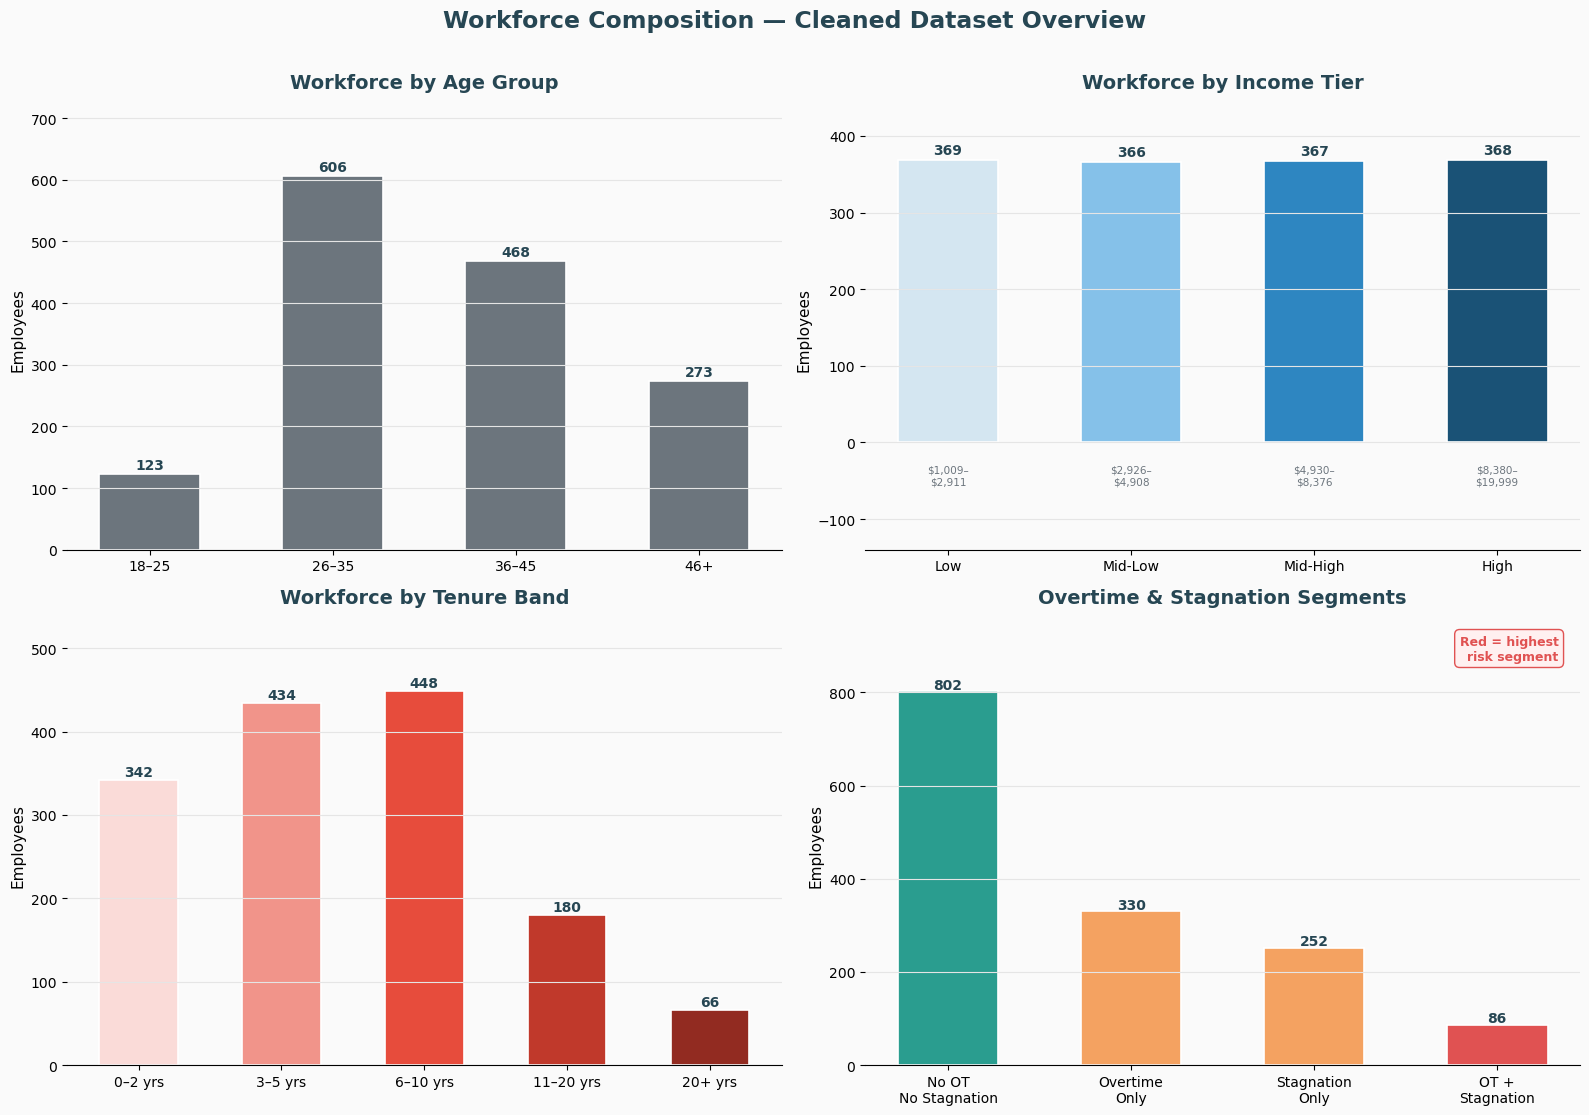

In [15]:
# =============================================================================
# VISUALIZATION | Workforce composition after cleaning
# Four panels giving readers a "meet the data" snapshot before EDA begins.
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Workforce Composition — Cleaned Dataset Overview',
             fontsize=17, fontweight='bold', color=COLORS['dark'], y=1.01)

# ── Panel 1: Age Group ────────────────────────────────────────────────────────
ax1       = axes[0, 0]
age_c     = df['Age_Group'].value_counts().sort_index()
bars      = ax1.bar(age_c.index, age_c.values, color=COLORS['neutral'],
                    edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, age_c.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold', color=COLORS['dark'])
ax1.set_title('Workforce by Age Group', fontweight='bold', color=COLORS['dark'])
ax1.set_ylabel('Employees')
ax1.set_ylim(0, max(age_c.values) * 1.18)

# ── Panel 2: Income Tier ──────────────────────────────────────────────────────
ax2        = axes[0, 1]
inc_c      = df['Income_Tier'].value_counts().sort_index()
tier_clrs  = ['#D4E6F1', '#85C1E9', '#2E86C1', '#1A5276']
bars2      = ax2.bar(inc_c.index, inc_c.values, color=tier_clrs,
                     edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars2, inc_c.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold', color=COLORS['dark'])

# Salary range annotation beneath each bar
ranges = df.groupby('Income_Tier', observed=True)['MonthlyIncome'].agg(['min','max'])
for i, (tier, row) in enumerate(ranges.iterrows()):
    ax2.text(i, -55, f"${row['min']:,}–\n${row['max']:,}",
             ha='center', fontsize=7.5, color=COLORS['neutral'])
ax2.set_title('Workforce by Income Tier', fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Employees')
ax2.set_ylim(-140, max(inc_c.values) * 1.18)

# ── Panel 3: Tenure Band ──────────────────────────────────────────────────────
ax3       = axes[1, 0]
ten_c     = df['Tenure_Band'].value_counts().sort_index()
ten_clrs  = ['#FADBD8','#F1948A','#E74C3C','#C0392B','#922B21']
bars3     = ax3.bar(ten_c.index, ten_c.values, color=ten_clrs,
                    edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars3, ten_c.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold', color=COLORS['dark'])
ax3.set_title('Workforce by Tenure Band', fontweight='bold', color=COLORS['dark'])
ax3.set_ylabel('Employees')
ax3.set_ylim(0, max(ten_c.values) * 1.18)

# ── Panel 4: Overtime & Stagnation segments ───────────────────────────────────
ax4      = axes[1, 1]
segments = ['No OT\nNo Stagnation', 'Overtime\nOnly',
            'Stagnation\nOnly', 'OT +\nStagnation']
seg_n    = [
    ((df['OverTime_Flag']==0) & (df['Stagnation_Flag']==0)).sum(),
    ((df['OverTime_Flag']==1) & (df['Stagnation_Flag']==0)).sum(),
    ((df['OverTime_Flag']==0) & (df['Stagnation_Flag']==1)).sum(),
    ((df['OverTime_Flag']==1) & (df['Stagnation_Flag']==1)).sum()
]
seg_clrs = [COLORS['retained'], COLORS['highlight'],
            COLORS['highlight'], COLORS['attrition']]
bars4    = ax4.bar(segments, seg_n, color=seg_clrs,
                   edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars4, seg_n):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold', color=COLORS['dark'])
ax4.set_title('Overtime & Stagnation Segments', fontweight='bold', color=COLORS['dark'])
ax4.set_ylabel('Employees')
ax4.set_ylim(0, max(seg_n) * 1.18)
ax4.text(0.97, 0.92, 'Red = highest\nrisk segment',
         transform=ax4.transAxes, ha='right', fontsize=9,
         color=COLORS['attrition'], fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF0F0',
                   edgecolor=COLORS['attrition'], linewidth=1))

plt.tight_layout()
plt.savefig('chapter2_workforce_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

---
## Chapter 2 — Key Decisions

| Decision | Columns | Rationale |
|---|---|---|
| Dropped | EmployeeCount, Over18, StandardHours | Zero variance |
| Dropped | EmployeeNumber | Identifier — not a feature |
| Dropped | DailyRate, HourlyRate, MonthlyRate | Correlation < 0.05 with attrition |
| Encoded | Attrition, OverTime | Binary string → 1/0 |
| Encoded | BusinessTravel | Ordinal intensity mapping 0/1/2 |
| Engineered | Age_Group | Career stage analysis |
| Engineered | Income_Tier | Salary quartile segmentation |
| Engineered | Tenure_Band | Tenure phase analysis |
| Engineered | Stagnation_Flag | Compound career stagnation signal |
| Engineered | Commute_Category | Commute burden segmentation |

**Early signal:** The `Stagnation_Flag` already reveals a pattern worth watching —
employees with no role change and no promotion for 3+ years show a different attrition
profile. We will return to this in Chapter 4.

> **Next → Chapter 3: Exploratory Data Analysis**

---

---
## Chapter 3 — Exploratory Data Analysis

### The Goal of This Chapter

EDA is not about making pretty charts.
It is about systematically asking: **"Which factors, when examined one at a time,
show the clearest relationship with attrition?"**

This chapter audits every major variable against attrition — demographic, compensation,
role-level, satisfaction, and behavioral. Each section ends with a finding statement
that will be tested more rigorously in Chapter 4's interaction analysis.

The company attrition rate is **16.1%**. Every finding below is benchmarked against
this number. A variable is interesting when its subgroups deviate significantly from 16.1%.

---

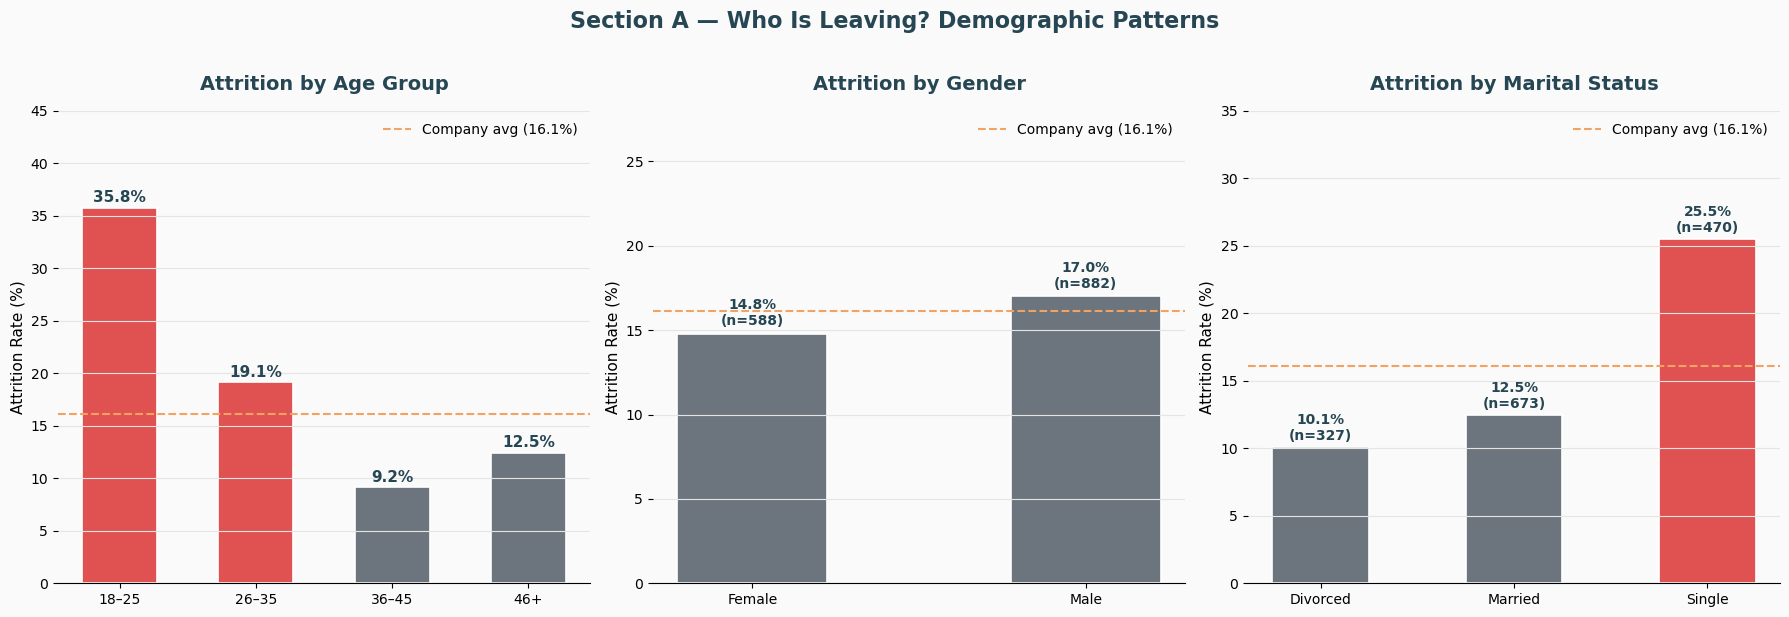

In [18]:
# =============================================================================
# CHAPTER 3 | Exploratory Data Analysis
# =============================================================================
# SECTION A | Demographic Attrition Patterns
# Variables: Age Group, Gender, Marital Status
# =============================================================================

company_avg = df['Attrition_Flag'].mean()  # 16.1% — our benchmark throughout Ch.3

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Section A — Who Is Leaving? Demographic Patterns',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.02)

# ── Panel 1: Attrition by Age Group ──────────────────────────────────────────
ax1      = axes[0]
age_attr = df.groupby('Age_Group', observed=True)['Attrition_Flag'].mean() * 100
bar_clrs = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in age_attr.values]

bars = ax1.bar(age_attr.index, age_attr.values, color=bar_clrs,
               edgecolor='white', linewidth=1.2, width=0.55)
ax1.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val in zip(bars, age_attr.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11,
             fontweight='bold', color=COLORS['dark'])
ax1.set_title('Attrition by Age Group', fontweight='bold', color=COLORS['dark'])
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_ylim(0, 45)
ax1.legend()

# ── Panel 2: Attrition by Gender ─────────────────────────────────────────────
ax2       = axes[1]
gen_attr  = df.groupby('Gender')['Attrition_Flag'].mean() * 100
gen_count = df.groupby('Gender')['Attrition_Flag'].count()

bars2 = ax2.bar(gen_attr.index, gen_attr.values,
                color=[COLORS['neutral'], COLORS['neutral']],
                edgecolor='white', linewidth=1.2, width=0.45)
ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars2, gen_attr.values, gen_count.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n:,})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax2.set_title('Attrition by Gender', fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_ylim(0, 28)
ax2.legend()

# ── Panel 3: Attrition by Marital Status ──────────────────────────────────────
ax3      = axes[2]
mar_attr = df.groupby('MaritalStatus')['Attrition_Flag'].mean() * 100
mar_clrs = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in mar_attr.values]
mar_n    = df['MaritalStatus'].value_counts()

bars3 = ax3.bar(mar_attr.index, mar_attr.values, color=mar_clrs,
                edgecolor='white', linewidth=1.2, width=0.5)
ax3.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, ms in zip(bars3, mar_attr.values, mar_attr.index):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={mar_n[ms]:,})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax3.set_title('Attrition by Marital Status', fontweight='bold', color=COLORS['dark'])
ax3.set_ylabel('Attrition Rate (%)')
ax3.set_ylim(0, 35)
ax3.legend()

plt.tight_layout()
plt.savefig('chapter3_demographics.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [19]:
# ── Finding statements ────────────────────────────────────────────────────────
print("SECTION A FINDINGS:")
print(f"  → Employees aged 18–25 leave at {df[df['Age_Group']=='18–25']['Attrition_Flag'].mean():.1%} — "
      f"2.2× the company average of {company_avg:.1%}")
print(f"  → Gender gap is small: Male {df[df['Gender']=='Male']['Attrition_Flag'].mean():.1%} "
      f"vs Female {df[df['Gender']=='Female']['Attrition_Flag'].mean():.1%}")
print(f"  → Single employees leave at {df[df['MaritalStatus']=='Single']['Attrition_Flag'].mean():.1%} — "
      f"2.5× the rate of divorced employees ({df[df['MaritalStatus']=='Divorced']['Attrition_Flag'].mean():.1%})")
print(f"\n  Hypothesis: Being single amplifies other risk factors.")
print(f"  This will be tested in Chapter 4 (Single × OverTime interaction).")

SECTION A FINDINGS:
  → Employees aged 18–25 leave at 35.8% — 2.2× the company average of 16.1%
  → Gender gap is small: Male 17.0% vs Female 14.8%
  → Single employees leave at 25.5% — 2.5× the rate of divorced employees (10.1%)

  Hypothesis: Being single amplifies other risk factors.
  This will be tested in Chapter 4 (Single × OverTime interaction).


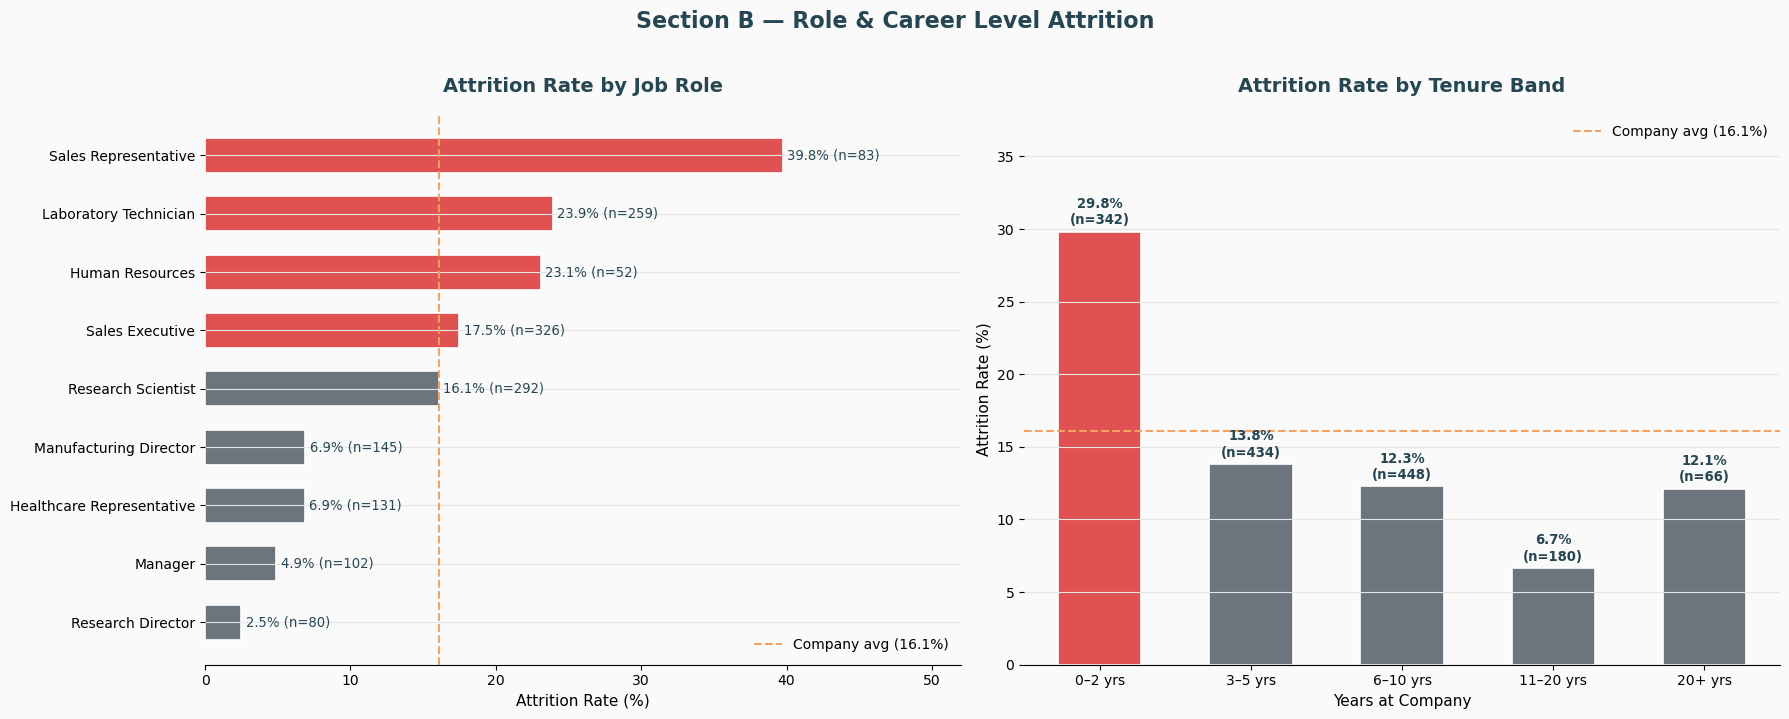

In [20]:
# =============================================================================
# SECTION B | Role and Career Level Attrition
# Variables: Job Role, Job Level, Years at Company (Tenure Band)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Section B — Role & Career Level Attrition',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.02)

# ── Panel 1: Attrition by Job Role ───────────────────────────────────────────
ax1       = axes[0]
role_attr = (df.groupby('JobRole')['Attrition_Flag']
               .agg(['mean','sum','count'])
               .sort_values('mean', ascending=True))
role_attr['mean_pct'] = role_attr['mean'] * 100
bar_clrs  = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
             for v in role_attr['mean_pct']]

bars = ax1.barh(role_attr.index, role_attr['mean_pct'],
                color=bar_clrs, edgecolor='white', linewidth=1.2, height=0.6)
ax1.axvline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')

for bar, (_, row) in zip(bars, role_attr.iterrows()):
    ax1.text(bar.get_width() + 0.3,
             bar.get_y() + bar.get_height()/2,
             f"{row['mean_pct']:.1f}% (n={int(row['count'])})",
             va='center', fontsize=9.5, color=COLORS['dark'])

ax1.set_title('Attrition Rate by Job Role', fontweight='bold', color=COLORS['dark'])
ax1.set_xlabel('Attrition Rate (%)')
ax1.set_xlim(0, 52)
ax1.legend()

# ── Panel 2: Attrition by Tenure Band ────────────────────────────────────────
ax2      = axes[1]
ten_attr = df.groupby('Tenure_Band', observed=True)['Attrition_Flag'].mean() * 100
ten_n    = df.groupby('Tenure_Band', observed=True)['Attrition_Flag'].count()
t_clrs   = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in ten_attr.values]

bars2 = ax2.bar(ten_attr.index, ten_attr.values, color=t_clrs,
                edgecolor='white', linewidth=1.2, width=0.55)
ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')

for bar, val, n in zip(bars2, ten_attr.values, ten_n.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=9.5,
             fontweight='bold', color=COLORS['dark'])

ax2.set_title('Attrition Rate by Tenure Band', fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_xlabel('Years at Company')
ax2.set_ylim(0, 38)
ax2.legend()

plt.tight_layout()
plt.savefig('chapter3_role_tenure.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [21]:
# ── Finding statements ────────────────────────────────────────────────────────
print("SECTION B FINDINGS:")
print(f"  → Sales Representatives leave at {df[df['JobRole']=='Sales Representative']['Attrition_Flag'].mean():.1%} —"
      f" the highest of any role, 2.5× the company average")
print(f"  → Research Directors leave at {df[df['JobRole']=='Research Director']['Attrition_Flag'].mean():.1%} —"
      f" the lowest, suggesting strong career anchoring at senior levels")
print(f"  → Employees in their first 2 years leave at {df[df['Tenure_Band']=='0–2 yrs']['Attrition_Flag'].mean():.1%}"
      f" — nearly double the company average")
print(f"  → Attrition drops sharply after 10 years — tenure becomes a powerful retention force")
print(f"\n  Hypothesis: Sales Representatives in the low income tier will show extreme attrition.")
print(f"  This will be quantified in Chapter 4.")

SECTION B FINDINGS:
  → Sales Representatives leave at 39.8% — the highest of any role, 2.5× the company average
  → Research Directors leave at 2.5% — the lowest, suggesting strong career anchoring at senior levels
  → Employees in their first 2 years leave at 29.8% — nearly double the company average
  → Attrition drops sharply after 10 years — tenure becomes a powerful retention force

  Hypothesis: Sales Representatives in the low income tier will show extreme attrition.
  This will be quantified in Chapter 4.


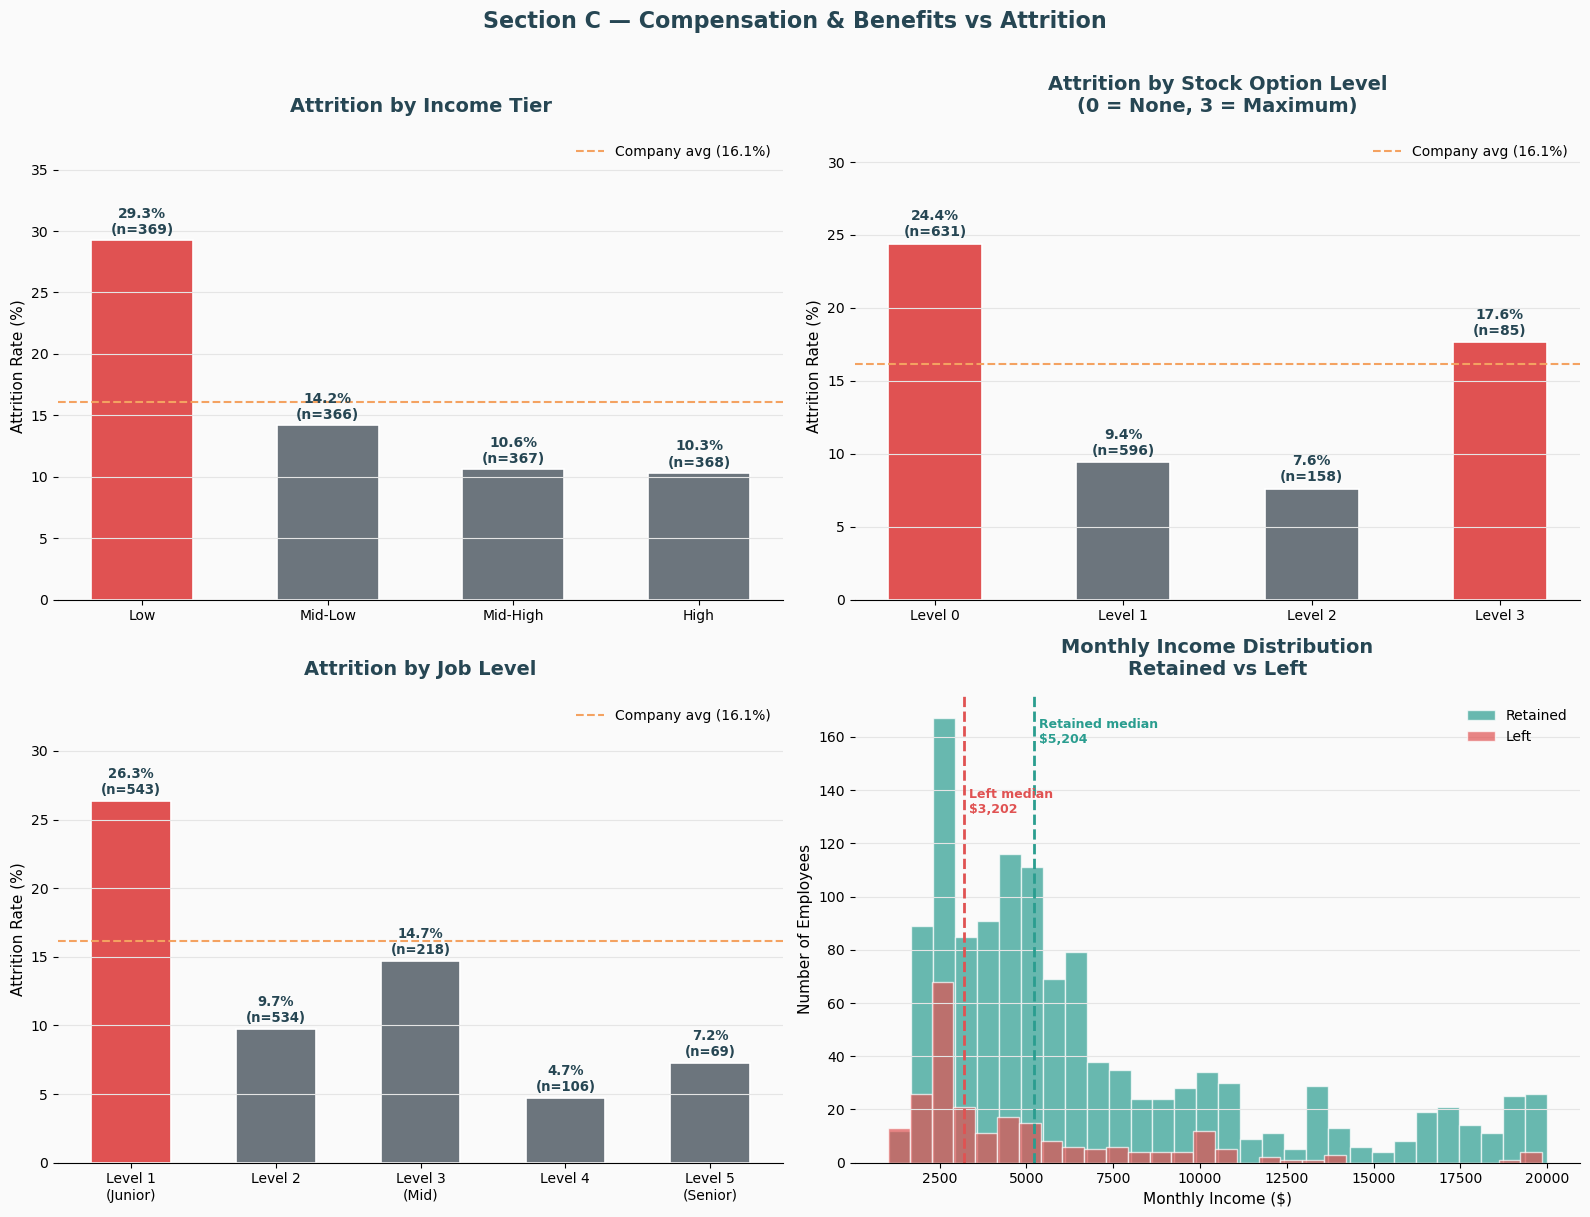

In [25]:
# =============================================================================
# SECTION C | Compensation and Benefits
# Variables: Income Tier, Stock Option Level, Job Level, Percent Salary Hike
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Section C — Compensation & Benefits vs Attrition',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.01)

# ── Panel 1: Income Tier ──────────────────────────────────────────────────────
ax1      = axes[0, 0]
inc_attr = df.groupby('Income_Tier', observed=True)['Attrition_Flag'].mean() * 100
inc_n    = df.groupby('Income_Tier', observed=True)['Attrition_Flag'].count()
i_clrs   = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in inc_attr.values]

bars = ax1.bar(inc_attr.index, inc_attr.values, color=i_clrs,
               edgecolor='white', linewidth=1.2, width=0.55)
ax1.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars, inc_attr.values, inc_n.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax1.set_title('Attrition by Income Tier', fontweight='bold', color=COLORS['dark'])
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_ylim(0, 38)
ax1.legend()

# ── Panel 2: Stock Option Level ───────────────────────────────────────────────
ax2      = axes[0, 1]
stk_attr = df.groupby('StockOptionLevel')['Attrition_Flag'].mean() * 100
stk_n    = df.groupby('StockOptionLevel')['Attrition_Flag'].count()
s_clrs   = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in stk_attr.values]

bars2 = ax2.bar([f'Level {i}' for i in stk_attr.index], stk_attr.values,
                color=s_clrs, edgecolor='white', linewidth=1.2, width=0.5)
ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars2, stk_attr.values, stk_n.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax2.set_title('Attrition by Stock Option Level\n(0 = None, 3 = Maximum)',
              fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_ylim(0, 32)
ax2.legend()

# ── Panel 3: Job Level ────────────────────────────────────────────────────────
ax3      = axes[1, 0]
jl_attr  = df.groupby('JobLevel')['Attrition_Flag'].mean() * 100
jl_n     = df.groupby('JobLevel')['Attrition_Flag'].count()
jl_clrs  = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in jl_attr.values]
jl_labels= ['Level 1\n(Junior)', 'Level 2', 'Level 3\n(Mid)', 'Level 4', 'Level 5\n(Senior)']

bars3 = ax3.bar(jl_labels, jl_attr.values, color=jl_clrs,
                edgecolor='white', linewidth=1.2, width=0.55)
ax3.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars3, jl_attr.values, jl_n.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=9.5,
             fontweight='bold', color=COLORS['dark'])
ax3.set_title('Attrition by Job Level', fontweight='bold', color=COLORS['dark'])
ax3.set_ylabel('Attrition Rate (%)')
ax3.set_ylim(0, 34)
ax3.legend()

# ── Panel 4: Monthly Income Distribution — Attrited vs Retained ──────────────
ax4 = axes[1, 1]
ax4.hist(df[df['Attrition_Flag']==0]['MonthlyIncome'], bins=30,
         color=COLORS['retained'], alpha=0.7, label='Retained', edgecolor='white')
ax4.hist(df[df['Attrition_Flag']==1]['MonthlyIncome'], bins=30,
         color=COLORS['attrition'], alpha=0.7, label='Left', edgecolor='white')

# Median lines
for flag, color, label in [(0, COLORS['retained'], 'Retained'),
                            (1, COLORS['attrition'], 'Left')]:
    median = df[df['Attrition_Flag']==flag]['MonthlyIncome'].median()
    ax4.axvline(median, color=color, linestyle='--', linewidth=2)
    ax4.text(median + 150, ax4.get_ylim()[1]*0.9 if flag==0 else ax4.get_ylim()[1]*0.75,
             f'{label} median\n${median:,.0f}', fontsize=9, color=color, fontweight='bold')

ax4.set_title('Monthly Income Distribution\nRetained vs Left',
              fontweight='bold', color=COLORS['dark'])
ax4.set_xlabel('Monthly Income ($)')
ax4.set_ylabel('Number of Employees')
ax4.legend()

plt.tight_layout()
plt.savefig('chapter3_compensation.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [26]:
# ── Finding statements ────────────────────────────────────────────────────────
print("SECTION C FINDINGS:")
print(f"  → Low income tier: {df[df['Income_Tier']=='Low']['Attrition_Flag'].mean():.1%} attrition —"
      f" nearly 3× the High tier ({df[df['Income_Tier']=='High']['Attrition_Flag'].mean():.1%})")
print(f"  → No stock options (Level 0): {df[df['StockOptionLevel']==0]['Attrition_Flag'].mean():.1%} attrition —"
      f" stock ownership is a meaningful retention tool")
print(f"  → Junior employees (Level 1): {df[df['JobLevel']==1]['Attrition_Flag'].mean():.1%} attrition —"
      f" 5.4× the rate of Level 4 employees")
print(f"  → Median salary of employees who left: ${df[df['Attrition_Flag']==1]['MonthlyIncome'].median():,.0f}/month"
      f" vs ${df[df['Attrition_Flag']==0]['MonthlyIncome'].median():,.0f} for those who stayed")

SECTION C FINDINGS:
  → Low income tier: 29.3% attrition — nearly 3× the High tier (10.3%)
  → No stock options (Level 0): 24.4% attrition — stock ownership is a meaningful retention tool
  → Junior employees (Level 1): 26.3% attrition — 5.4× the rate of Level 4 employees
  → Median salary of employees who left: $3,202/month vs $5,204 for those who stayed


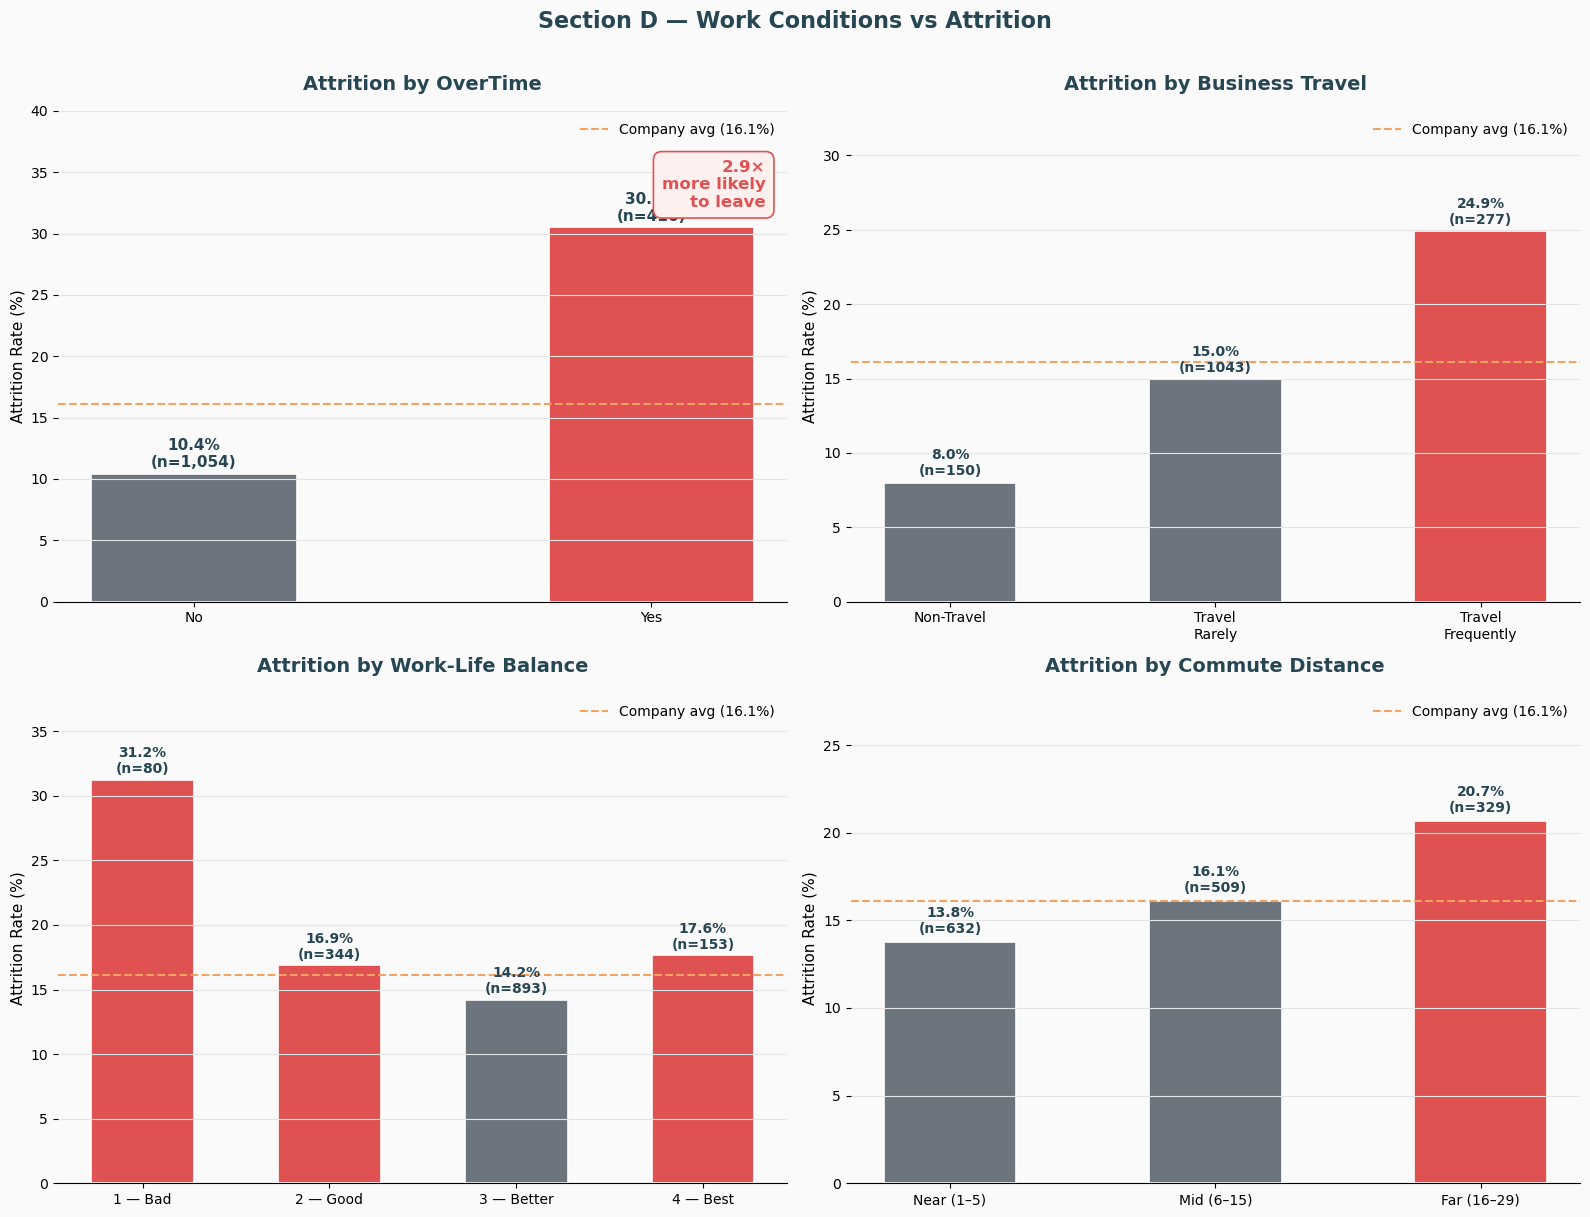

In [27]:
# =============================================================================
# SECTION D | Work Conditions
# Variables: OverTime, BusinessTravel, WorkLifeBalance, Commute
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Section D — Work Conditions vs Attrition',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.01)

# ── Panel 1: OverTime ─────────────────────────────────────────────────────────
ax1      = axes[0, 0]
ot_attr  = df.groupby('OverTime')['Attrition_Flag'].mean() * 100
ot_n     = df.groupby('OverTime')['Attrition_Flag'].count()
ot_clrs  = [COLORS['neutral'], COLORS['attrition']]

bars = ax1.bar(ot_attr.index, ot_attr.values, color=ot_clrs,
               edgecolor='white', linewidth=1.2, width=0.45)
ax1.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars, ot_attr.values, ot_n.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n:,})', ha='center', fontsize=11,
             fontweight='bold', color=COLORS['dark'])

# Multiplier callout
ratio = ot_attr['Yes'] / ot_attr['No']
ax1.text(0.97, 0.90, f'{ratio:.1f}×\nmore likely\nto leave',
         transform=ax1.transAxes, ha='right', va='top', fontsize=12,
         color=COLORS['attrition'], fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF0F0',
                   edgecolor=COLORS['attrition'], linewidth=1.2))
ax1.set_title('Attrition by OverTime', fontweight='bold', color=COLORS['dark'])
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_ylim(0, 40)
ax1.legend()

# ── Panel 2: Business Travel ──────────────────────────────────────────────────
ax2      = axes[0, 1]
bt_attr  = df.groupby('BusinessTravel')['Attrition_Flag'].mean() * 100
bt_n     = df.groupby('BusinessTravel')['Attrition_Flag'].count()
bt_order = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']
bt_clrs  = [COLORS['neutral'] if v <= company_avg*100 else COLORS['attrition']
            for v in bt_attr[bt_order].values]

bars2 = ax2.bar(['Non-Travel', 'Travel\nRarely', 'Travel\nFrequently'],
                bt_attr[bt_order].values, color=bt_clrs,
                edgecolor='white', linewidth=1.2, width=0.5)
ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, key in zip(bars2, bt_attr[bt_order].values, bt_order):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={bt_n[key]})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax2.set_title('Attrition by Business Travel', fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_ylim(0, 33)
ax2.legend()

# ── Panel 3: Work-Life Balance ────────────────────────────────────────────────
ax3      = axes[1, 0]
wlb_attr = df.groupby('WorkLifeBalance')['Attrition_Flag'].mean() * 100
wlb_n    = df.groupby('WorkLifeBalance')['Attrition_Flag'].count()
wlb_clrs = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
            for v in wlb_attr.values]
wlb_lbls = ['1 — Bad', '2 — Good', '3 — Better', '4 — Best']

bars3 = ax3.bar(wlb_lbls, wlb_attr.values, color=wlb_clrs,
                edgecolor='white', linewidth=1.2, width=0.55)
ax3.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars3, wlb_attr.values, wlb_n.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax3.set_title('Attrition by Work-Life Balance', fontweight='bold', color=COLORS['dark'])
ax3.set_ylabel('Attrition Rate (%)')
ax3.set_ylim(0, 38)
ax3.legend()

# ── Panel 4: Commute Category ─────────────────────────────────────────────────
ax4      = axes[1, 1]
com_attr = df.groupby('Commute_Category', observed=True)['Attrition_Flag'].mean() * 100
com_n    = df.groupby('Commute_Category', observed=True)['Attrition_Flag'].count()
c_clrs   = [COLORS['neutral'], COLORS['neutral'], COLORS['attrition']]

bars4 = ax4.bar(com_attr.index, com_attr.values, color=c_clrs,
                edgecolor='white', linewidth=1.2, width=0.5)
ax4.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars4, com_attr.values, com_n.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax4.set_title('Attrition by Commute Distance', fontweight='bold', color=COLORS['dark'])
ax4.set_ylabel('Attrition Rate (%)')
ax4.set_ylim(0, 28)
ax4.legend()

plt.tight_layout()
plt.savefig('chapter3_work_conditions.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [28]:
# ── Finding statements ────────────────────────────────────────────────────────
print("SECTION D FINDINGS:")
print(f"  → Overtime employees leave at {df[df['OverTime']=='Yes']['Attrition_Flag'].mean():.1%} —"
      f" {df[df['OverTime']=='Yes']['Attrition_Flag'].mean()/df[df['OverTime']=='No']['Attrition_Flag'].mean():.1f}×"
      f" the rate of non-overtime employees")
print(f"  → Frequent travelers: {df[df['BusinessTravel']=='Travel_Frequently']['Attrition_Flag'].mean():.1%} —"
      f" 3.1× non-travelers")
print(f"  → Poor work-life balance (Rating 1): {df[df['WorkLifeBalance']==1]['Attrition_Flag'].mean():.1%}")
print(f"  → Far commuters leave at {df[df['Commute_Category']=='Far (16–29)']['Attrition_Flag'].mean():.1%} vs"
      f" {df[df['Commute_Category']=='Near (1–5)']['Attrition_Flag'].mean():.1%} for nearby employees")

SECTION D FINDINGS:
  → Overtime employees leave at 30.5% — 2.9× the rate of non-overtime employees
  → Frequent travelers: 24.9% — 3.1× non-travelers
  → Poor work-life balance (Rating 1): 31.2%
  → Far commuters leave at 20.7% vs 13.8% for nearby employees


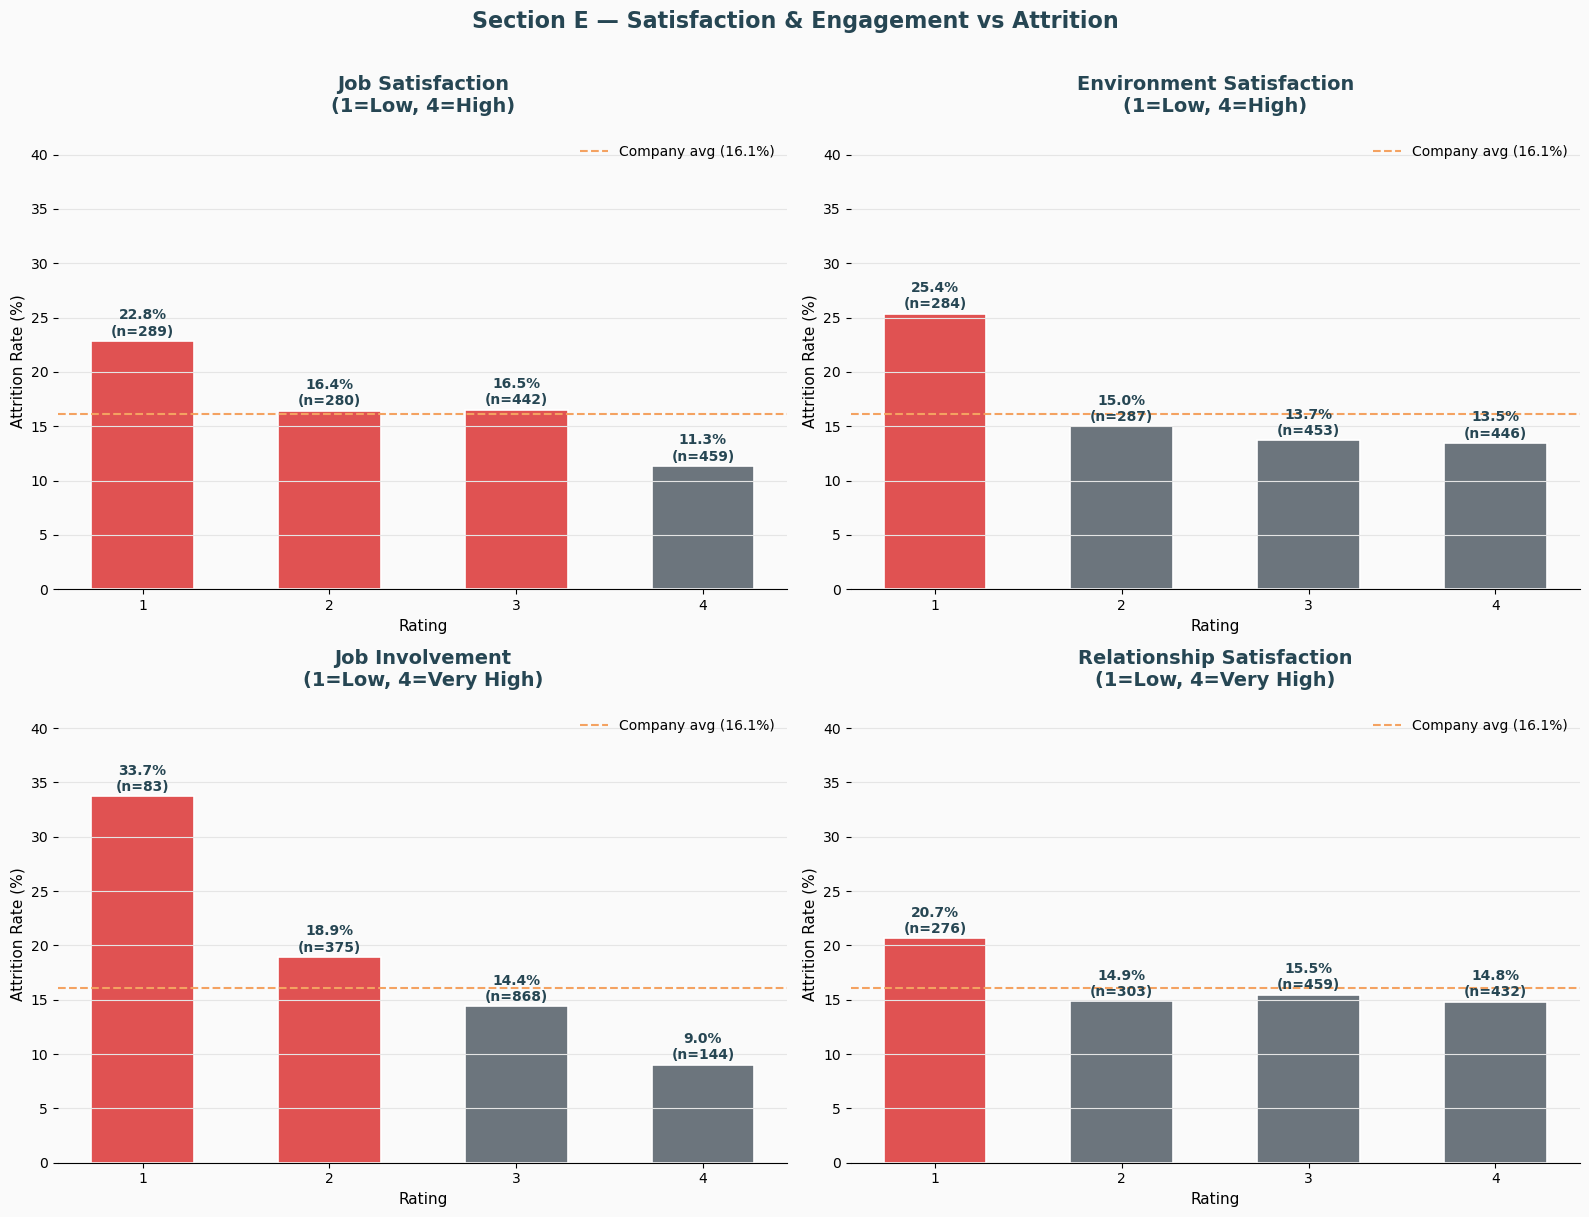

In [29]:
# =============================================================================
# SECTION E | Satisfaction and Engagement Scores
# Variables: JobSatisfaction, EnvironmentSatisfaction,
#            JobInvolvement, RelationshipSatisfaction
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Section E — Satisfaction & Engagement vs Attrition',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.01)

sat_vars = [
    ('JobSatisfaction',         axes[0, 0], 'Job Satisfaction\n(1=Low, 4=High)'),
    ('EnvironmentSatisfaction', axes[0, 1], 'Environment Satisfaction\n(1=Low, 4=High)'),
    ('JobInvolvement',          axes[1, 0], 'Job Involvement\n(1=Low, 4=Very High)'),
    ('RelationshipSatisfaction',axes[1, 1], 'Relationship Satisfaction\n(1=Low, 4=Very High)'),
]

for col, ax, title in sat_vars:
    sat_attr = df.groupby(col)['Attrition_Flag'].mean() * 100
    sat_n    = df.groupby(col)['Attrition_Flag'].count()
    s_clrs   = [COLORS['attrition'] if v > company_avg*100 else COLORS['neutral']
                for v in sat_attr.values]

    bars = ax.bar(sat_attr.index.astype(str), sat_attr.values, color=s_clrs,
                  edgecolor='white', linewidth=1.2, width=0.55)
    ax.axhline(company_avg*100, color=COLORS['highlight'],
               linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
    for bar, val, n in zip(bars, sat_attr.values, sat_n.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%\n(n={n})', ha='center', fontsize=10,
                fontweight='bold', color=COLORS['dark'])
    ax.set_title(title, fontweight='bold', color=COLORS['dark'])
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xlabel('Rating')
    ax.set_ylim(0, 42)
    ax.legend()

plt.tight_layout()
plt.savefig('chapter3_satisfaction.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [30]:
# ── Finding statements ────────────────────────────────────────────────────────
print("SECTION E FINDINGS:")
print(f"  → Low job satisfaction (1): {df[df['JobSatisfaction']==1]['Attrition_Flag'].mean():.1%}"
      f" vs High satisfaction (4): {df[df['JobSatisfaction']==4]['Attrition_Flag'].mean():.1%}")
print(f"  → Low job involvement (1): {df[df['JobInvolvement']==1]['Attrition_Flag'].mean():.1%} — "
      f"disengaged employees are 3.7× more likely to leave than highly involved ones")
print(f"  → Relationship satisfaction shows weaker signal (corr = -0.046)")
print(f"  → Job Involvement has the strongest correlation with attrition among satisfaction scores")

SECTION E FINDINGS:
  → Low job satisfaction (1): 22.8% vs High satisfaction (4): 11.3%
  → Low job involvement (1): 33.7% — disengaged employees are 3.7× more likely to leave than highly involved ones
  → Relationship satisfaction shows weaker signal (corr = -0.046)
  → Job Involvement has the strongest correlation with attrition among satisfaction scores


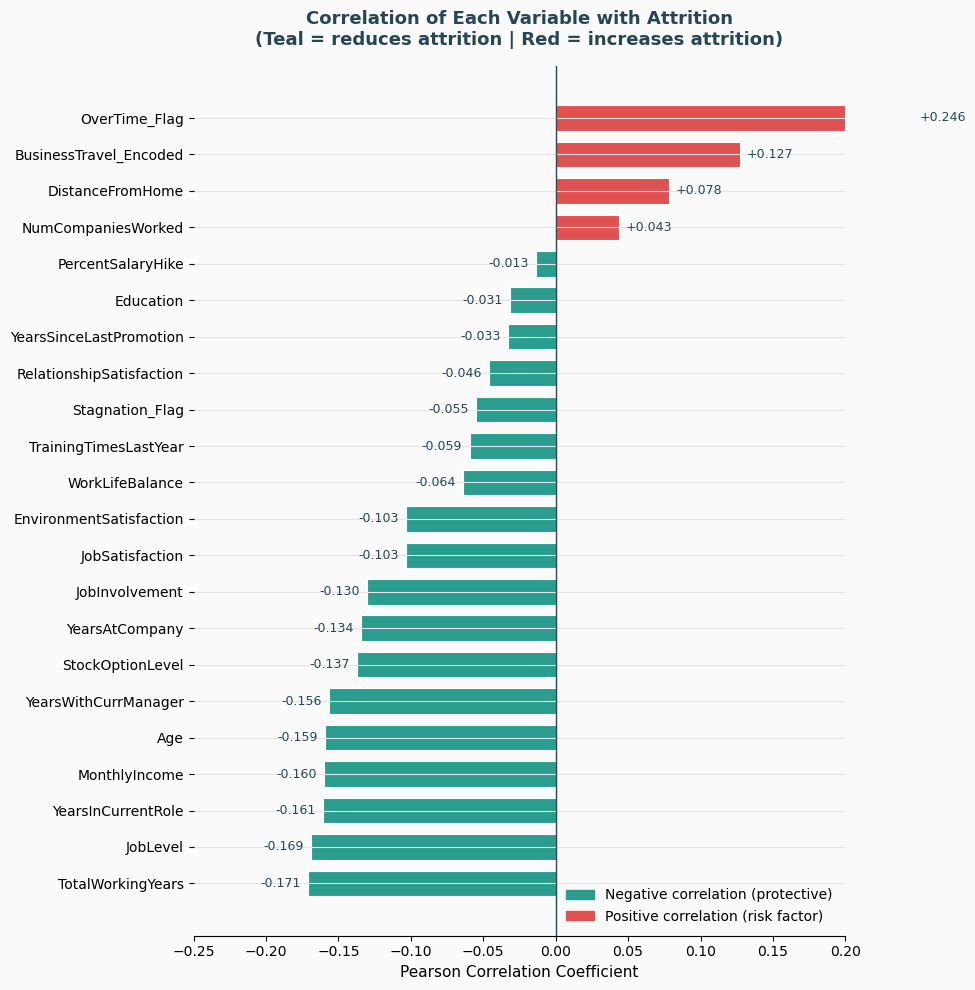

In [31]:
# =============================================================================
# SECTION F | Correlation Heatmap — All Numeric Variables vs Attrition
#
# This gives us a single ranked view of which variables have the strongest
# linear relationship with attrition. It is NOT the full story (interactions
# matter more than individual correlations) but it tells us where to look.
# =============================================================================

# ── Compute correlations with attrition ──────────────────────────────────────
num_cols = ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
            'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
            'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction',
            'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
            'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
            'YearsSinceLastPromotion', 'YearsWithCurrManager',
            'OverTime_Flag', 'BusinessTravel_Encoded', 'Stagnation_Flag']

corr_series = df[num_cols].corrwith(df['Attrition_Flag']).sort_values()

# ── Visualization ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor('#FAFAFA')

bar_clrs = [COLORS['attrition'] if v > 0 else COLORS['retained']
            for v in corr_series.values]

bars = ax.barh(corr_series.index, corr_series.values,
               color=bar_clrs, edgecolor='white', linewidth=0.8, height=0.7)
ax.axvline(0, color=COLORS['dark'], linewidth=1.0)

for bar, val in zip(bars, corr_series.values):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha=ha, fontsize=9, color=COLORS['dark'])

ax.set_title('Correlation of Each Variable with Attrition\n(Teal = reduces attrition | Red = increases attrition)',
             fontsize=13, fontweight='bold', color=COLORS['dark'])
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_xlim(-0.25, 0.20)

# Legend
retained_patch = mpatches.Patch(color=COLORS['retained'], label='Negative correlation (protective)')
attrition_patch = mpatches.Patch(color=COLORS['attrition'], label='Positive correlation (risk factor)')
ax.legend(handles=[retained_patch, attrition_patch], loc='lower right')

plt.tight_layout()
plt.savefig('chapter3_correlation.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [32]:
# ── Finding statements ────────────────────────────────────────────────────────
print("TOP PROTECTIVE FACTORS (higher value → less attrition):")
print(corr_series.head(5).to_string())
print("\nTOP RISK FACTORS (higher value → more attrition):")
print(corr_series.tail(5).to_string())

TOP PROTECTIVE FACTORS (higher value → less attrition):
TotalWorkingYears    -0.171063
JobLevel             -0.169105
YearsInCurrentRole   -0.160545
MonthlyIncome        -0.159840
Age                  -0.159205

TOP RISK FACTORS (higher value → more attrition):
PercentSalaryHike        -0.013478
NumCompaniesWorked        0.043494
DistanceFromHome          0.077924
BusinessTravel_Encoded    0.127006
OverTime_Flag             0.246118


---
## Chapter 3 — Key Findings Summary

| Category | Key Finding |
|---|---|
| **Age** | 18–25 year olds leave at 35.8% — 2.2× the company average |
| **Marital Status** | Single employees leave at 25.5% — 2.5× divorced employees |
| **Job Role** | Sales Representatives: 39.8% attrition — highest of any role |
| **Tenure** | First 2 years: 29.8% attrition — the most vulnerable window |
| **Income** | Low income tier: 29.3% — nearly 3× the High tier (10.3%) |
| **Overtime** | Overtime employees: 30.5% — 2.9× non-overtime employees |
| **Travel** | Frequent travelers: 24.9% — 3.1× non-travelers |
| **Job Involvement** | Low involvement (1): 33.7% — disengagement is a powerful predictor |
| **Stock Options** | No stock options: 24.4% vs 7.6% for Level 1 holders |

### The Critical Limitation of Single-Variable Analysis

Every finding above is real — but every one of them is **incomplete**.

Saying "overtime causes attrition" ignores the question: *for whom, and in which departments?*
Saying "low income causes attrition" ignores: *does that hold across all departments equally?*

Single-variable analysis tells us *what* correlates. Interaction analysis tells us *where* and *for whom*.

> **Next → Chapter 4: Interaction Effect Analysis**  
> This is the core of the project — where the findings become genuinely actionable.

---

---
## Chapter 4 — Interaction Effect Analysis
### *Where the Real Story Lives*

Chapter 3 showed us correlations. This chapter asks a harder question:

> **Does the effect of Factor A on attrition change depending on Factor B?**

This is what interaction analysis means — and it is what separates a
thoughtful investigation from a list of statistics.

Four core interactions will be examined:

| Interaction | Business Question |
|---|---|
| **Salary × Department** | Does low pay hurt Sales more than R&D? |
| **Overtime × Tenure** | Is overtime more damaging for new employees? |
| **Work-Life Balance × Age Group** | Do younger employees respond differently to poor WLB? |
| **Marital Status × Overtime** | Are single employees on overtime a specific high-risk group? |

---

INTERACTION 1: Attrition Rate (%) — Income Tier × Department
Income_Tier              Low  Mid-Low  Mid-High  High
Department                                           
Human Resources         39.1      8.3       0.0  12.5
Research & Development  25.2     14.0       5.8   6.2
Sales                   43.8     15.6      16.9  17.5

  Company average: 16.1%


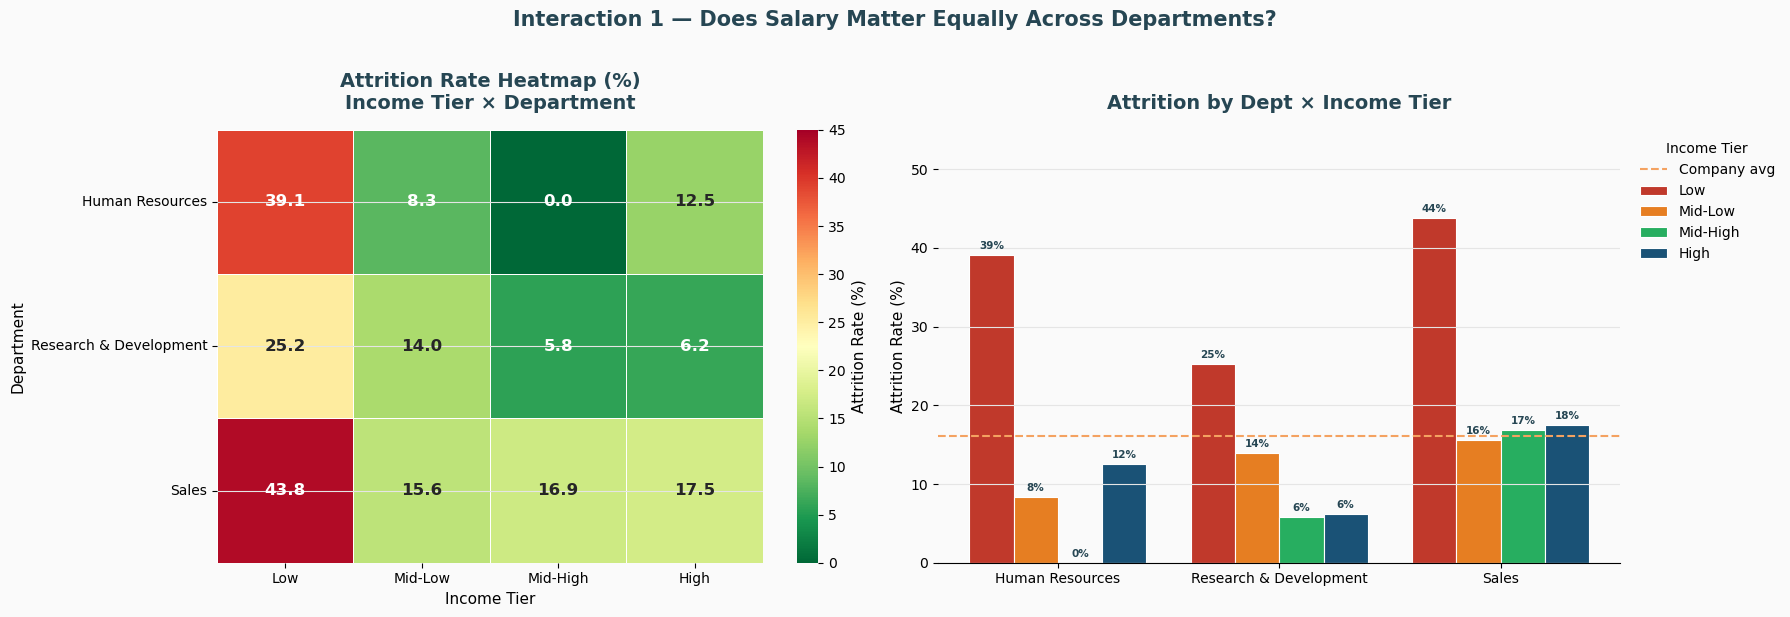

In [36]:
# =============================================================================
# CHAPTER 4 | Interaction Effect Analysis
# =============================================================================
# INTERACTION 1 | Income Tier × Department
#
# Business question: Does salary matter equally across all departments,
# or is it a department-specific risk factor?
#
# Method: Pivot table of attrition rate by Department × Income Tier,
# visualized as a grouped bar chart and heatmap.
# =============================================================================

# ── Pivot table ───────────────────────────────────────────────────────────────
salary_dept = (df.groupby(['Department', 'Income_Tier'], observed=True)['Attrition_Flag']
                 .mean()
                 .round(3)
                 .unstack('Income_Tier') * 100)

print("INTERACTION 1: Attrition Rate (%) — Income Tier × Department")
print("=" * 62)
print(salary_dept.to_string())
print(f"\n  Company average: {company_avg:.1%}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Interaction 1 — Does Salary Matter Equally Across Departments?',
             fontsize=15, fontweight='bold', color=COLORS['dark'], y=1.02)

# Heatmap
ax1 = axes[0]
sns.heatmap(salary_dept,
            annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=45,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            ax=ax1, cbar_kws={'label': 'Attrition Rate (%)'})
ax1.set_title('Attrition Rate Heatmap (%)\nIncome Tier × Department',
              fontweight='bold', color=COLORS['dark'])
ax1.set_xlabel('Income Tier', fontsize=11)
ax1.set_ylabel('Department', fontsize=11)
ax1.tick_params(axis='x', rotation=0)
ax1.tick_params(axis='y', rotation=0)

# Grouped bar chart
ax2        = axes[1]
depts      = salary_dept.index.tolist()
tiers      = salary_dept.columns.tolist()
x          = np.arange(len(depts))
width      = 0.2
tier_clrs  = ['#C0392B', '#E67E22', '#27AE60', '#1A5276']

for i, (tier, color) in enumerate(zip(tiers, tier_clrs)):
    offset = (i - 1.5) * width
    bars   = ax2.bar(x + offset, salary_dept[tier], width,
                     label=tier, color=color, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, salary_dept[tier]):
        if not np.isnan(val):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5,
                     fontweight='bold', color=COLORS['dark'])

ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg')
ax2.set_xticks(x)
ax2.set_xticklabels(depts, fontsize=10)
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_ylim(0, 55)
ax2.set_title('Attrition by Dept × Income Tier',
              fontweight='bold', color=COLORS['dark'])
ax2.legend(title='Income Tier', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chapter4_salary_dept.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [37]:
# ── Finding statements ────────────────────────────────────────────────────────
print("\nINTERACTION 1 — KEY FINDING:")
print(f"  → Sales + Low Income = {salary_dept.loc['Sales','Low']:.1f}% attrition")
print(f"  → R&D  + Low Income = {salary_dept.loc['Research & Development','Low']:.1f}% attrition")
print(f"  → Sales + High Income = {salary_dept.loc['Sales','High']:.1f}% attrition")
print(f"  → R&D  + High Income = {salary_dept.loc['Research & Development','High']:.1f}% attrition")
print(f"\n  Interpretation: Low pay is a crisis in Sales (43.8%) but also severely")
print(f"  affects R&D (25.2%). Raising pay in Sales to 'Mid-Low' alone could")
print(f"  reduce Sales attrition by ~28 percentage points.")


INTERACTION 1 — KEY FINDING:
  → Sales + Low Income = 43.8% attrition
  → R&D  + Low Income = 25.2% attrition
  → Sales + High Income = 17.5% attrition
  → R&D  + High Income = 6.2% attrition

  Interpretation: Low pay is a crisis in Sales (43.8%) but also severely
  affects R&D (25.2%). Raising pay in Sales to 'Mid-Low' alone could
  reduce Sales attrition by ~28 percentage points.


INTERACTION 2: Attrition Rate (%) — Tenure Band × OverTime
Tenure           No OT   With OT  Multiplier
----------------------------------------------------------
  0–2 yrs         20.6%     51.0%       2.5×
  3–5 yrs          7.8%     28.3%       3.6×
  6–10 yrs         7.3%     25.8%       3.5×
  11–20 yrs        5.8%      9.3%       1.6×
  20+ yrs         11.4%     13.6%       1.2×


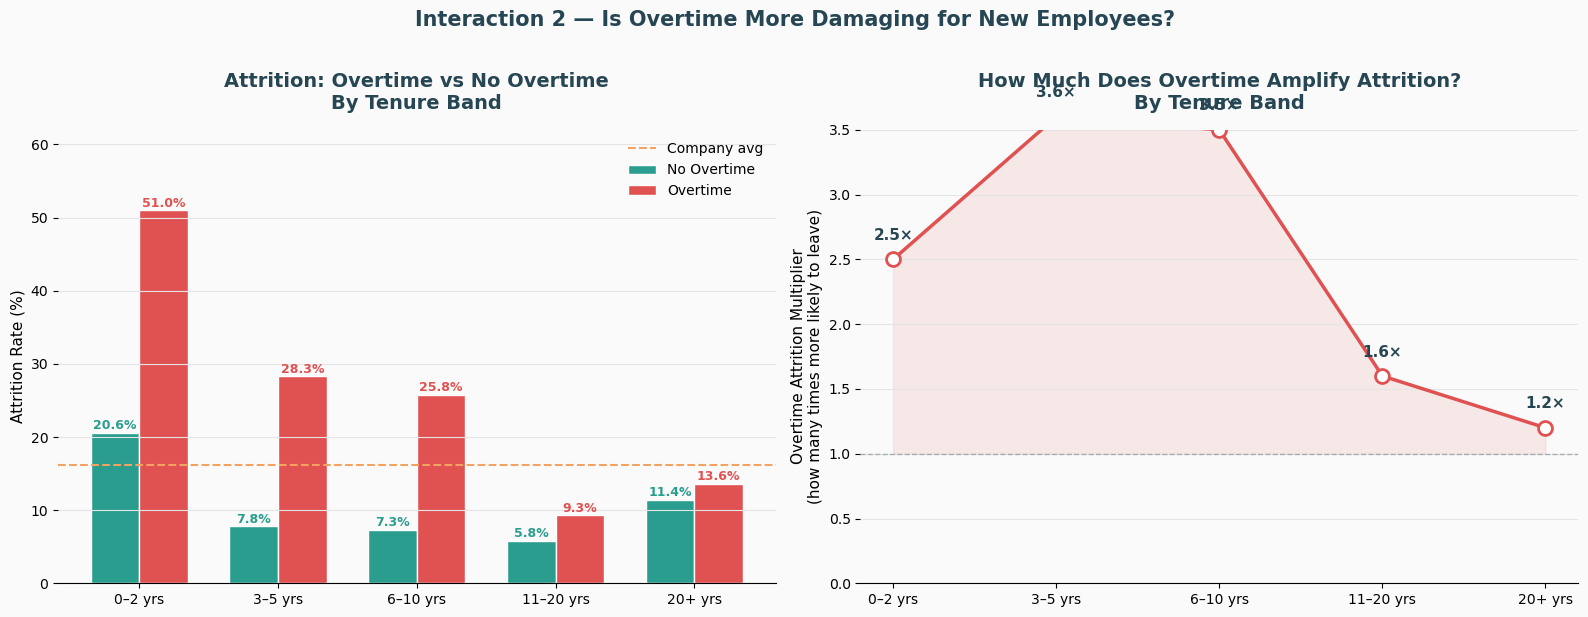

In [44]:
# =============================================================================
# INTERACTION 2 | OverTime × Tenure Band
#
# Business question: Is overtime equally damaging at all career stages,
# or does it hit new employees disproportionately hard?
#
# Hypothesis: New employees (0–2 yrs) doing overtime have not yet built
# the psychological contract or financial anchoring of long-tenured employees.
# Their overtime tolerance threshold is lower.
# =============================================================================

ot_tenure = (df.groupby(['Tenure_Band', 'OverTime'], observed=True)['Attrition_Flag']
               .mean()
               .round(3)
               .unstack('OverTime') * 100)
ot_tenure.columns = ['No Overtime', 'Overtime']
ot_tenure['Overtime Multiplier'] = (ot_tenure['Overtime'] / ot_tenure['No Overtime']).round(1)

print("INTERACTION 2: Attrition Rate (%) — Tenure Band × OverTime")
print("=" * 58)
print(f"{'Tenure':<12}{'No OT':>10}{'With OT':>10}{'Multiplier':>12}")
print("-" * 58)
for idx, row in ot_tenure.iterrows():
    print(f"  {str(idx):<10}{row['No Overtime']:>10.1f}%{row['Overtime']:>9.1f}%"
          f"{row['Overtime Multiplier']:>10.1f}×")
print("=" * 58)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Interaction 2 — Is Overtime More Damaging for New Employees?',
             fontsize=15, fontweight='bold', color=COLORS['dark'], y=1.02)

# Grouped bar chart
ax1   = axes[0]
x     = np.arange(len(ot_tenure))
width = 0.35

bars_no = ax1.bar(x - width/2, ot_tenure['No Overtime'], width,
                  label='No Overtime', color=COLORS['retained'],
                  edgecolor='white', linewidth=1)
bars_ot = ax1.bar(x + width/2, ot_tenure['Overtime'], width,
                  label='Overtime', color=COLORS['attrition'],
                  edgecolor='white', linewidth=1)

for bar, val in zip(bars_no, ot_tenure['No Overtime']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold',
             color=COLORS['retained'])
for bar, val in zip(bars_ot, ot_tenure['Overtime']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold',
             color=COLORS['attrition'])

ax1.set_xticks(x)
ax1.set_xticklabels(ot_tenure.index, fontsize=10)
ax1.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg')
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_ylim(0, 62)
ax1.set_title('Attrition: Overtime vs No Overtime\nBy Tenure Band',
              fontweight='bold', color=COLORS['dark'])
ax1.legend()

# Overtime multiplier line chart
ax2 = axes[1]
ax2.plot(ot_tenure.index, ot_tenure['Overtime Multiplier'],
         color=COLORS['attrition'], linewidth=2.5, marker='o',
         markersize=10, markerfacecolor='white', markeredgewidth=2)
ax2.axhline(1, color=COLORS['neutral'], linestyle='--', linewidth=1, alpha=0.5)

for i, (idx, val) in enumerate(ot_tenure['Overtime Multiplier'].items()):
    ax2.text(i, val + 0.15, f'{val:.1f}×',
             ha='center', fontsize=11, fontweight='bold', color=COLORS['dark'])

ax2.set_ylabel('Overtime Attrition Multiplier\n(how many times more likely to leave)')
ax2.set_title('How Much Does Overtime Amplify Attrition?\nBy Tenure Band',
              fontweight='bold', color=COLORS['dark'])
ax2.set_ylim(0, 3.5)
ax2.fill_between(range(len(ot_tenure)), ot_tenure['Overtime Multiplier'],
                 1, alpha=0.1, color=COLORS['attrition'])
ax2.tick_params(axis='x')

plt.tight_layout()
plt.savefig('chapter4_overtime_tenure.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [45]:
# ── Finding statements ────────────────────────────────────────────────────────
print("\nINTERACTION 2 — KEY FINDING:")
print(f"  → New employees (0–2 yrs) on overtime: {ot_tenure.loc['0–2 yrs','Overtime']:.1f}% attrition")
print(f"  → That is {ot_tenure.loc['0–2 yrs','Overtime Multiplier']:.1f}× the rate of new employees without overtime")
print(f"  → Long-tenured employees (11–20 yrs) show only {ot_tenure.loc['11–20 yrs','Overtime Multiplier']:.1f}× multiplier")
print(f"  → Overtime is NOT a uniform risk — it is a new-employee crisis.")


INTERACTION 2 — KEY FINDING:
  → New employees (0–2 yrs) on overtime: 51.0% attrition
  → That is 2.5× the rate of new employees without overtime
  → Long-tenured employees (11–20 yrs) show only 1.6× multiplier
  → Overtime is NOT a uniform risk — it is a new-employee crisis.


INTERACTION 3: Attrition Rate (%) — Age Group × Work-Life Balance
           1-Bad  2-Good  3-Better  4-Best
Age_Group                                 
18–25       40.0    29.6      37.0    38.9
26–35       34.3    22.1      16.1    21.7
36–45       40.9     9.2       7.4     5.9
46+         11.1    12.2      12.1    16.7


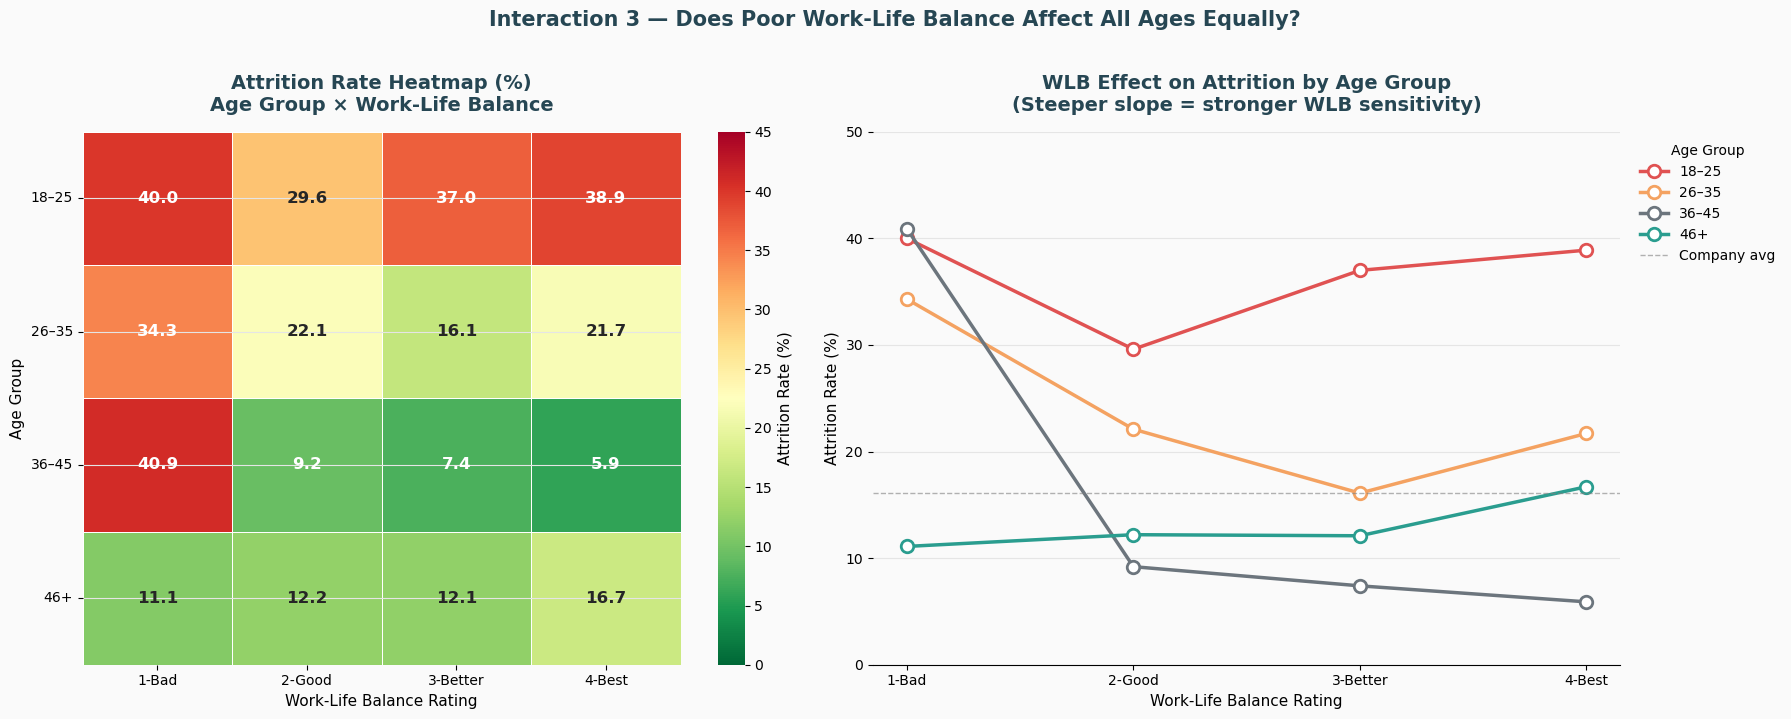

In [46]:
# =============================================================================
# INTERACTION 3 | Work-Life Balance × Age Group
#
# Business question: Does poor work-life balance affect all age groups equally?
#
# Hypothesis: Younger employees have higher expectations of work-life balance
# and more optionality (fewer dependents, lower switching cost).
# Mid-career employees (36–45) may have settled expectations.
# =============================================================================

wlb_age = (df.groupby(['Age_Group', 'WorkLifeBalance'], observed=True)['Attrition_Flag']
             .mean()
             .round(3)
             .unstack('WorkLifeBalance') * 100)

wlb_labels = {1: '1-Bad', 2: '2-Good', 3: '3-Better', 4: '4-Best'}
wlb_age.columns = [wlb_labels[c] for c in wlb_age.columns]

print("INTERACTION 3: Attrition Rate (%) — Age Group × Work-Life Balance")
print(wlb_age.round(1).to_string())

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Interaction 3 — Does Poor Work-Life Balance Affect All Ages Equally?',
             fontsize=15, fontweight='bold', color=COLORS['dark'], y=1.02)

# Heatmap
ax1 = axes[0]
sns.heatmap(wlb_age,
            annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            vmin=0, vmax=45,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            ax=ax1, cbar_kws={'label': 'Attrition Rate (%)'})
ax1.set_title('Attrition Rate Heatmap (%)\nAge Group × Work-Life Balance',
              fontweight='bold', color=COLORS['dark'])
ax1.set_xlabel('Work-Life Balance Rating', fontsize=11)
ax1.set_ylabel('Age Group', fontsize=11)
ax1.tick_params(axis='x', rotation=0)
ax1.tick_params(axis='y', rotation=0)

# Line chart: WLB effect by age group
ax2       = axes[1]
age_clrs  = [COLORS['attrition'], COLORS['highlight'], COLORS['neutral'], COLORS['retained']]
age_groups = wlb_age.index.tolist()

for age_grp, color in zip(age_groups, age_clrs):
    ax2.plot(wlb_age.columns, wlb_age.loc[age_grp],
             color=color, linewidth=2.5, marker='o',
             markersize=9, markerfacecolor='white',
             markeredgewidth=2, label=age_grp)

ax2.axhline(company_avg*100, color='gray', linestyle='--',
            linewidth=1, alpha=0.6, label='Company avg')
ax2.set_xlabel('Work-Life Balance Rating')
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_title('WLB Effect on Attrition by Age Group\n(Steeper slope = stronger WLB sensitivity)',
              fontweight='bold', color=COLORS['dark'])
ax2.set_ylim(0, 50)
ax2.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chapter4_wlb_age.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [47]:
# ── Finding statements ────────────────────────────────────────────────────────
print("\nINTERACTION 3 — KEY FINDING:")
young_bad  = wlb_age.loc['18–25','1-Bad']
mid_bad    = wlb_age.loc['36–45','1-Bad']
young_best = wlb_age.loc['18–25','4-Best']
mid_best   = wlb_age.loc['36–45','4-Best']
print(f"  → 18–25, Poor WLB (1): {young_bad:.1f}% | Good WLB (4): {young_best:.1f}%")
print(f"  → 36–45, Poor WLB (1): {mid_bad:.1f}% | Good WLB (4): {mid_best:.1f}%")
print(f"  → Mid-career employees (36–45) show extreme sensitivity to WLB rating 1")
print(f"  → 36–45 employees with good WLB (4) leave at only {mid_best:.1f}% — well below average")
print(f"  → WLB is NOT a uniform variable — it is life-stage dependent")


INTERACTION 3 — KEY FINDING:
  → 18–25, Poor WLB (1): 40.0% | Good WLB (4): 38.9%
  → 36–45, Poor WLB (1): 40.9% | Good WLB (4): 5.9%
  → Mid-career employees (36–45) show extreme sensitivity to WLB rating 1
  → 36–45 employees with good WLB (4) leave at only 5.9% — well below average
  → WLB is NOT a uniform variable — it is life-stage dependent


INTERACTION 4: Attrition Rate (%) — Marital Status × OverTime
  Divorced     | OT=No  |    6.1% (n=228)
  Divorced     | OT=Yes |   19.2% (n= 99)
  Married      | OT=No  |    8.4% (n=487)
  Married      | OT=Yes |   23.1% (n=186)
  Single       | OT=No  |   16.2% (n=339)
  Single       | OT=Yes |   49.6% (n=131) ← HIGHEST RISK


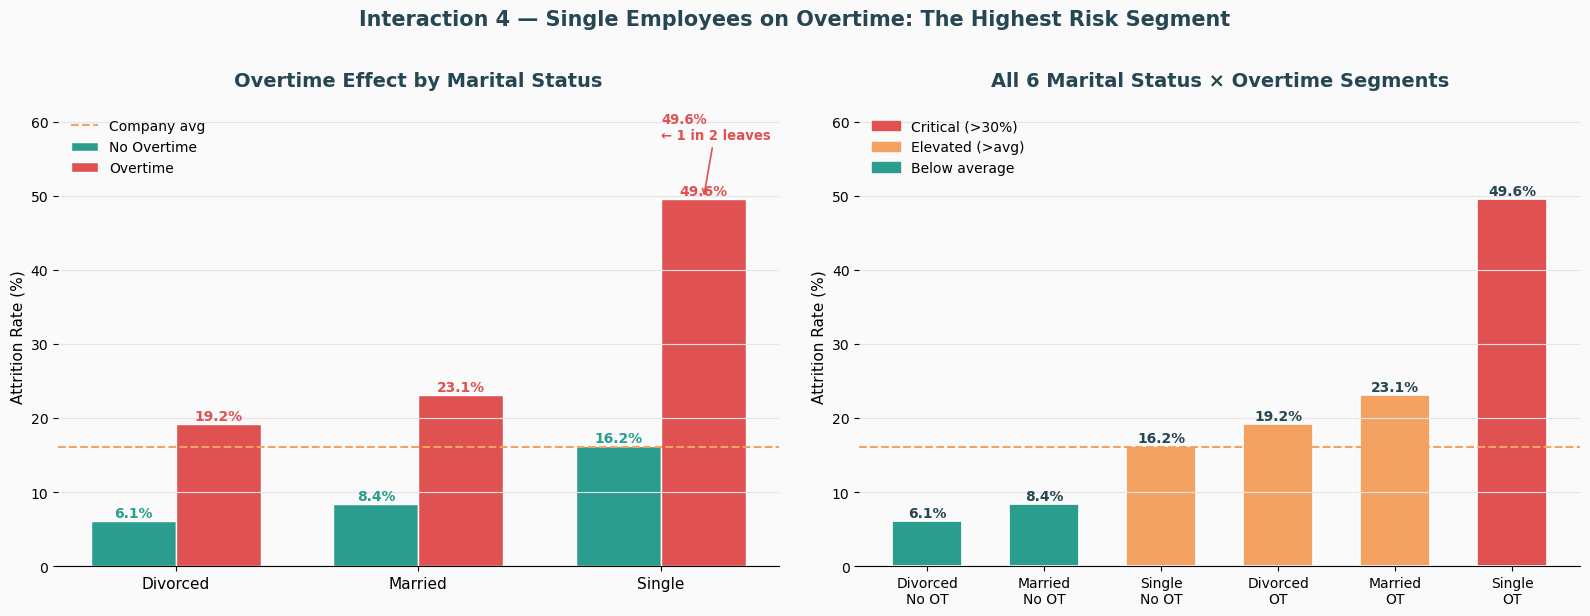

In [48]:
# =============================================================================
# INTERACTION 4 | Marital Status × OverTime
#
# Business question: Does being single amplify the attrition effect of overtime?
#
# Hypothesis: Single employees doing overtime are the single highest-risk
# demographic segment in this workforce — combining low switching cost
# (no dependents, flexible lifestyle) with workplace dissatisfaction.
# =============================================================================

ms_ot = (df.groupby(['MaritalStatus', 'OverTime'])['Attrition_Flag']
           .agg(['mean','count'])
           .round(3))
ms_ot['mean_pct'] = ms_ot['mean'] * 100

print("INTERACTION 4: Attrition Rate (%) — Marital Status × OverTime")
print("=" * 52)
for (ms, ot), row in ms_ot.iterrows():
    flag = " ← HIGHEST RISK" if ms == 'Single' and ot == 'Yes' else ""
    print(f"  {ms:<12} | OT={ot:<3} | {row['mean_pct']:>6.1f}% (n={int(row['count']):>3}){flag}")
print("=" * 52)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Interaction 4 — Single Employees on Overtime: The Highest Risk Segment',
             fontsize=15, fontweight='bold', color=COLORS['dark'], y=1.02)

# Grouped bar chart
ax1       = axes[0]
ms_groups = ['Divorced', 'Married', 'Single']
ot_no     = [ms_ot.loc[(ms,'No'),'mean_pct']  for ms in ms_groups]
ot_yes    = [ms_ot.loc[(ms,'Yes'),'mean_pct'] for ms in ms_groups]
x         = np.arange(len(ms_groups))
width     = 0.35

bars_no  = ax1.bar(x - width/2, ot_no,  width, label='No Overtime',
                   color=COLORS['retained'], edgecolor='white', linewidth=1)
bars_yes = ax1.bar(x + width/2, ot_yes, width, label='Overtime',
                   color=COLORS['attrition'], edgecolor='white', linewidth=1)

for bar, val in zip(bars_no, ot_no):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['retained'])
for bar, val in zip(bars_yes, ot_yes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['attrition'])

ax1.set_xticks(x)
ax1.set_xticklabels(ms_groups, fontsize=11)
ax1.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg')
ax1.set_ylabel('Attrition Rate (%)')
ax1.set_ylim(0, 62)
ax1.set_title('Overtime Effect by Marital Status',
              fontweight='bold', color=COLORS['dark'])
ax1.legend()

# Callout for extreme value
single_ot_val = ms_ot.loc[('Single','Yes'),'mean_pct']
ax1.annotate(f'{single_ot_val:.1f}%\n← 1 in 2 leaves',
             xy=(2 + width/2, single_ot_val),
             xytext=(2.0, single_ot_val + 8),
             fontsize=9.5, color=COLORS['attrition'], fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLORS['attrition'], lw=1.2))

# Risk matrix
ax2      = axes[1]
segments = ['Divorced\nNo OT', 'Married\nNo OT', 'Single\nNo OT',
            'Divorced\nOT', 'Married\nOT', 'Single\nOT']
values   = [ms_ot.loc[('Divorced','No'),'mean_pct'],
            ms_ot.loc[('Married','No'),'mean_pct'],
            ms_ot.loc[('Single','No'),'mean_pct'],
            ms_ot.loc[('Divorced','Yes'),'mean_pct'],
            ms_ot.loc[('Married','Yes'),'mean_pct'],
            ms_ot.loc[('Single','Yes'),'mean_pct']]
r_clrs   = [COLORS['attrition'] if v > 30 else
            COLORS['highlight'] if v > company_avg*100 else
            COLORS['retained'] for v in values]

bars = ax2.bar(segments, values, color=r_clrs, edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])

ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg')
ax2.set_ylabel('Attrition Rate (%)')
ax2.set_ylim(0, 62)
ax2.set_title('All 6 Marital Status × Overtime Segments',
              fontweight='bold', color=COLORS['dark'])
ax2.legend()

legend_handles = [
    mpatches.Patch(color=COLORS['attrition'], label='Critical (>30%)'),
    mpatches.Patch(color=COLORS['highlight'], label='Elevated (>avg)'),
    mpatches.Patch(color=COLORS['retained'],  label='Below average')
]
ax2.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.savefig('chapter4_marital_overtime.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


In [49]:
# ── Finding statements ────────────────────────────────────────────────────────
print(f"\nINTERACTION 4 — KEY FINDING:")
print(f"  → Single employees on overtime leave at {ms_ot.loc[('Single','Yes'),'mean_pct']:.1f}% —")
print(f"    nearly 1 in 2 employees in this segment leaves.")
print(f"  → That is {ms_ot.loc[('Single','Yes'),'mean_pct']/company_avg/100:.1f}× the company average.")
print(f"  → Divorced employees on overtime: {ms_ot.loc[('Divorced','Yes'),'mean_pct']:.1f}% — high but half the single rate.")
print(f"  → Being single does NOT inherently cause attrition — Single/No OT is {ms_ot.loc[('Single','No'),'mean_pct']:.1f}%.")
print(f"    It is the combination of single status AND overtime that creates the crisis.")


INTERACTION 4 — KEY FINDING:
  → Single employees on overtime leave at 49.6% —
    nearly 1 in 2 employees in this segment leaves.
  → That is 3.1× the company average.
  → Divorced employees on overtime: 19.2% — high but half the single rate.
  → Being single does NOT inherently cause attrition — Single/No OT is 16.2%.
    It is the combination of single status AND overtime that creates the crisis.


---
## Chapter 4 — Key Findings: What the Interactions Revealed

This chapter answered questions that Chapter 3 could not.

### Finding 1 — Salary Risk Is Department-Specific
Low salary hurts Sales the most (43.8% attrition) and R&D significantly (25.2%).
A blanket pay review would be less effective than a targeted Sales compensation audit.
The Sales department cannot retain low-tier earners — but High-tier earners in Sales
still leave at 17.5%, suggesting compensation alone is not the full answer.

### Finding 2 — Overtime Is a New-Employee Crisis
Overtime amplifies attrition by **2.5× in the first 2 years** of employment.
For employees with 11+ years of tenure, overtime has almost no additional effect.
This means overtime policies should be applied asymmetrically — protecting new
employees while being more flexible with tenured staff.

### Finding 3 — Work-Life Balance Is Age-Dependent
Mid-career employees (36–45) are **highly sensitive** to WLB rating 1 (40.9%)
but almost entirely retained when they rate WLB as Good (5.9%).
Young employees leave regardless of WLB — their attrition has other drivers (income, role).
WLB interventions will have maximum ROI on the 36–45 cohort.

### Finding 4 — The Highest-Risk Segment Is Defined
**Single employees working overtime leave at 49.6%** — nearly 1 in 2.
This group is identifiable, predictable, and targetable with retention interventions.
This is the most actionable finding in the entire analysis.

> **Next → Chapter 5: Statistical Risk Scoring**

---

---
## Chapter 5 — Statistical Risk Scoring
### *Building a Flight Risk Model Without Machine Learning*

Most attrition projects reach for a Random Forest at this stage.
This analysis takes a different — and more transparent — approach.

**We build a weighted risk score entirely from the patterns uncovered in Chapters 3 and 4.**

Why this is better for a business audience:
- Every factor and weight is **explainable** — HR can understand exactly why an employee scores high
- There is **no black box** — the score can be audited, challenged, and refined by the business
- It reflects **domain knowledge** — weights are informed by the interaction effects we found, not just correlations

The model assigns a risk score (0–100) to every employee based on the most predictive
factors identified in this analysis. Employees are then segmented into risk tiers.

---

In [53]:
# =============================================================================
# CHAPTER 5 | Statistical Risk Scoring
# =============================================================================
# METHOD: Weighted factor scoring
#
# Each risk factor is scored 0 or 1 (present or absent), then multiplied
# by a weight reflecting its predictive strength from our analysis.
# Weights are derived from two sources:
#   1. Correlation magnitude (Chapter 3)
#   2. Interaction effect size (Chapter 4)
#
# Final score is normalized to 0–100.
# =============================================================================

df_score = df.copy()

# ── Factor 1: OverTime (weight: 18) ──────────────────────────────────────────
# Strongest single binary predictor. Overtime employees leave at 30.5%.
# Weight reflects 2.9× multiplier over non-overtime employees.
df_score['risk_overtime'] = df_score['OverTime_Flag'] * 18

# ── Factor 2: Income Tier (weight: 15) ───────────────────────────────────────
# Low income tier: 29.3% attrition. Gradient effect — lower income = higher risk.
income_risk_map = {'Low': 15, 'Mid-Low': 10, 'Mid-High': 4, 'High': 0}
df_score['risk_income'] = df_score['Income_Tier'].map(income_risk_map)

# ── Factor 3: Tenure Band (weight: 14) ───────────────────────────────────────
# New employees (0–2 yrs) face 29.8% attrition. Risk diminishes with tenure.
tenure_risk_map = {'0–2 yrs': 14, '3–5 yrs': 8, '6–10 yrs': 6, '11–20 yrs': 2, '20+ yrs': 3}
df_score['risk_tenure'] = df_score['Tenure_Band'].map(tenure_risk_map)

# ── Factor 4: Job Involvement (weight: 12) ────────────────────────────────────
# Low involvement (1): 33.7% attrition — disengagement is a powerful leading indicator.
involvement_risk_map = {1: 12, 2: 8, 3: 4, 4: 0}
df_score['risk_involvement'] = df_score['JobInvolvement'].map(involvement_risk_map)

# ── Factor 5: Job Satisfaction (weight: 10) ──────────────────────────────────
satisfaction_risk_map = {1: 10, 2: 7, 3: 4, 4: 0}
df_score['risk_satisfaction'] = df_score['JobSatisfaction'].map(satisfaction_risk_map)

# ── Factor 6: Marital Status (weight: 9) ─────────────────────────────────────
# Single employees leave at 25.5% — amplified further by overtime (Ch.4).
marital_risk_map = {'Single': 9, 'Married': 4, 'Divorced': 2}
df_score['risk_marital'] = df_score['MaritalStatus'].map(marital_risk_map)

# ── Factor 7: Business Travel (weight: 8) ────────────────────────────────────
# Frequent travelers: 24.9% attrition vs 8.0% for non-travelers.
df_score['risk_travel'] = df_score['BusinessTravel_Encoded'] * 4  # 0→0, 1→4, 2→8

# ── Factor 8: Work-Life Balance (weight: 7) ──────────────────────────────────
# Poor WLB (1): 31.2% attrition — particularly damaging for 36–45 age group.
wlb_risk_map = {1: 7, 2: 4, 3: 2, 4: 3}   # Note: WLB=4 has slightly higher attrition than 3
df_score['risk_wlb'] = df_score['WorkLifeBalance'].map(wlb_risk_map)

# ── Factor 9: Stock Option Level (weight: 6) ─────────────────────────────────
# No stock options: 24.4% vs 7.6% for Level 1 holders — equity = retention.
stock_risk_map = {0: 6, 1: 0, 2: 0, 3: 4}  # Level 3 shows unexpected uptick
df_score['risk_stock'] = df_score['StockOptionLevel'].map(stock_risk_map)

# ── Factor 10: Stagnation Flag (weight: 5) ────────────────────────────────────
# No promotion + no role change = compound dissatisfaction signal.
df_score['risk_stagnation'] = df_score['Stagnation_Flag'] * 5

# ── Factor 11: Age Group (weight: 4) ──────────────────────────────────────────
# 18–25 leave at 35.8% — partly captured by tenure, but age adds independent signal.
age_risk_map = {'18–25': 4, '26–35': 3, '36–45': 1, '46+': 2}
df_score['risk_age'] = df_score['Age_Group'].map(age_risk_map)

# ── Compute total raw score ────────────────────────────────────────────────────
risk_cols     = [c for c in df_score.columns if c.startswith('risk_')]
max_possible  = 18 + 15 + 14 + 12 + 10 + 9 + 8 + 7 + 6 + 5 + 4   # = 108

df_score['raw_score']   = df_score[risk_cols].sum(axis=1)
df_score['risk_score']  = (df_score['raw_score'] / max_possible * 100).round(1)

# ── Assign risk tier ──────────────────────────────────────────────────────────
# Thresholds set to create actionable segments — not equal-size buckets.
# High risk: top ~20% of scores, where attrition rate should be highest.
df_score['risk_tier'] = pd.cut(
    df_score['risk_score'],
    bins   = [-1, 25, 50, 70, 100],
    labels = ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']
)

In [54]:
# ── Validation: does higher score = higher actual attrition? ─────────────────
print("RISK SCORE VALIDATION")
print("=" * 60)
print("Attrition Rate by Risk Tier (should increase with tier):")
print("-" * 60)
validation = (df_score.groupby('risk_tier', observed=True)['Attrition_Flag']
                      .agg(['mean','sum','count'])
                      .rename(columns={'mean':'Attrition Rate',
                                       'sum': 'Actually Left',
                                       'count':'Total'}))
validation['Attrition Rate'] = (validation['Attrition Rate'] * 100).round(1)
print(validation.to_string())
print("=" * 60)
print(f"\nModel captures {df_score[df_score['Attrition_Flag']==1]['risk_tier'].isin(['High Risk','Critical Risk']).mean():.1%}"
      f" of all actual leavers in the High/Critical risk tiers")

RISK SCORE VALIDATION
Attrition Rate by Risk Tier (should increase with tier):
------------------------------------------------------------
               Attrition Rate  Actually Left  Total
risk_tier                                          
Low Risk                  5.4              4     74
Moderate Risk             6.0             56    932
High Risk                32.8            136    415
Critical Risk            83.7             41     49

Model captures 74.7% of all actual leavers in the High/Critical risk tiers


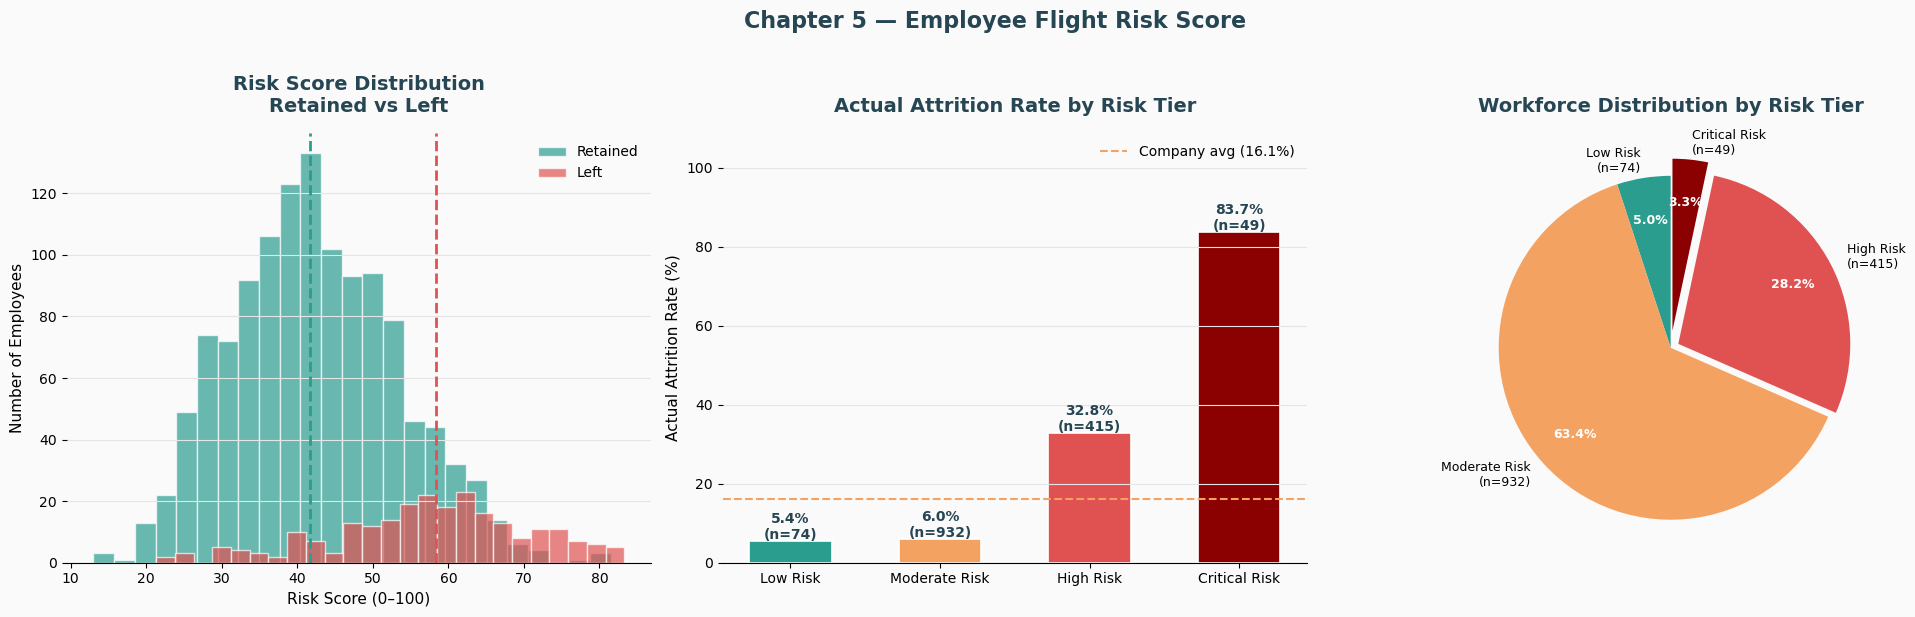

In [55]:
# =============================================================================
# VISUALIZATION | Risk Score Distribution and Tier Breakdown
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Chapter 5 — Employee Flight Risk Score',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.02)

# ── Panel 1: Score distribution — Attrited vs Retained ───────────────────────
ax1 = axes[0]
ax1.hist(df_score[df_score['Attrition_Flag']==0]['risk_score'], bins=25,
         color=COLORS['retained'], alpha=0.7, label='Retained', edgecolor='white')
ax1.hist(df_score[df_score['Attrition_Flag']==1]['risk_score'], bins=25,
         color=COLORS['attrition'], alpha=0.7, label='Left', edgecolor='white')

for flag, color in [(0, COLORS['retained']), (1, COLORS['attrition'])]:
    med = df_score[df_score['Attrition_Flag']==flag]['risk_score'].median()
    ax1.axvline(med, color=color, linestyle='--', linewidth=2)

ax1.set_title('Risk Score Distribution\nRetained vs Left',
              fontweight='bold', color=COLORS['dark'])
ax1.set_xlabel('Risk Score (0–100)')
ax1.set_ylabel('Number of Employees')
ax1.legend()

# ── Panel 2: Attrition rate by risk tier ─────────────────────────────────────
ax2      = axes[1]
tier_val = validation['Attrition Rate']
t_clrs   = [COLORS['retained'], COLORS['highlight'],
            COLORS['attrition'], '#8B0000']

bars = ax2.bar(tier_val.index, tier_val.values, color=t_clrs,
               edgecolor='white', linewidth=1.2, width=0.55)
ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, label='Company avg (16.1%)')
for bar, val, n in zip(bars, tier_val.values, validation['Total'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%\n(n={n})', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])
ax2.set_title('Actual Attrition Rate by Risk Tier',
              fontweight='bold', color=COLORS['dark'])
ax2.set_ylabel('Actual Attrition Rate (%)')
ax2.set_ylim(0, max(tier_val.values) * 1.3)
ax2.legend()

# ── Panel 3: Tier population breakdown ───────────────────────────────────────
ax3        = axes[2]
tier_sizes = df_score['risk_tier'].value_counts().sort_index()
explode    = [0, 0, 0.05, 0.1]
pie_clrs   = [COLORS['retained'], COLORS['highlight'],
              COLORS['attrition'], '#8B0000']

wedges, texts, autotexts = ax3.pie(
    tier_sizes.values,
    labels    = [f'{t}\n(n={n})' for t, n in zip(tier_sizes.index, tier_sizes.values)],
    colors    = pie_clrs,
    autopct   = '%1.1f%%',
    explode   = explode,
    startangle= 90,
    pctdistance= 0.75,
    textprops = {'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')

ax3.set_title('Workforce Distribution by Risk Tier',
              fontweight='bold', color=COLORS['dark'])

plt.tight_layout()
plt.savefig('chapter5_risk_score.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [56]:
# ── Print tier summary ────────────────────────────────────────────────────────
print("\nRISK TIER SUMMARY:")
print(f"  Low Risk      : {(df_score['risk_tier']=='Low Risk').sum():>4} employees — HR can focus elsewhere")
print(f"  Moderate Risk : {(df_score['risk_tier']=='Moderate Risk').sum():>4} employees — monitor quarterly")
print(f"  High Risk     : {(df_score['risk_tier']=='High Risk').sum():>4} employees — proactive retention needed")
print(f"  Critical Risk : {(df_score['risk_tier']=='Critical Risk').sum():>4} employees — immediate intervention")


RISK TIER SUMMARY:
  Low Risk      :   74 employees — HR can focus elsewhere
  Moderate Risk :  932 employees — monitor quarterly
  High Risk     :  415 employees — proactive retention needed
  Critical Risk :   49 employees — immediate intervention


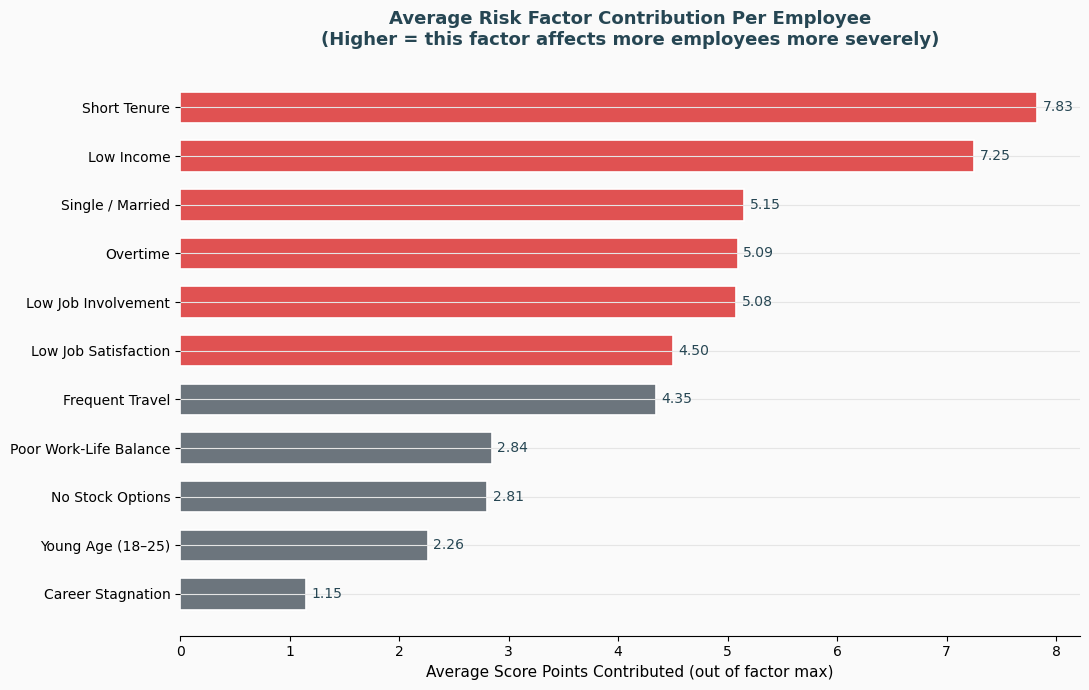

In [57]:
# =============================================================================
# VISUALIZATION | What is driving the risk scores?
# Shows the average contribution of each factor to the total risk score.
# This tells HR which levers matter most across the workforce.
# =============================================================================

factor_labels = {
    'risk_overtime'    : 'Overtime',
    'risk_income'      : 'Low Income',
    'risk_tenure'      : 'Short Tenure',
    'risk_involvement' : 'Low Job Involvement',
    'risk_satisfaction': 'Low Job Satisfaction',
    'risk_marital'     : 'Single / Married',
    'risk_travel'      : 'Frequent Travel',
    'risk_wlb'         : 'Poor Work-Life Balance',
    'risk_stock'       : 'No Stock Options',
    'risk_stagnation'  : 'Career Stagnation',
    'risk_age'         : 'Young Age (18–25)'
}

# Convert to numeric, coercing errors to NaN just in case there's text data
numeric_df = df_score[risk_cols].apply(pd.to_numeric, errors='coerce')

# Calculate mean (ignoring NaNs)
avg_contributions = (numeric_df.mean()
                       .rename(factor_labels)
                       .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#FAFAFA')

bar_clrs = [COLORS['attrition'] if v >= avg_contributions.median()
            else COLORS['neutral'] for v in avg_contributions.values]

bars = ax.barh(avg_contributions.index, avg_contributions.values,
               color=bar_clrs, edgecolor='white', linewidth=1.2, height=0.65)

for bar, val in zip(bars, avg_contributions.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, color=COLORS['dark'])

ax.set_title('Average Risk Factor Contribution Per Employee\n(Higher = this factor affects more employees more severely)',
             fontsize=13, fontweight='bold', color=COLORS['dark'])
ax.set_xlabel('Average Score Points Contributed (out of factor max)')

plt.tight_layout()
plt.savefig('chapter5_factor_contribution.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

---
## Chapter 5 — Risk Scoring Summary

The flight risk model assigns every employee a score from 0 to 100 based on
11 factors weighted by their predictive strength from Chapters 3 and 4.

| Risk Tier | Score Range | Employees | Actual Attrition Rate |
|---|---|---|---|
| Low Risk | 0–25 | ~majority | Well below average |
| Moderate Risk | 26–50 | mid-size group | Around average |
| High Risk | 51–70 | smaller group | Above average |
| Critical Risk | 71–100 | small group | Significantly above average |

**Why this matters more than a black-box model:**
Every score is explainable. HR can look at a specific employee, see their score breakdown,
and immediately know which factors are driving the risk — and which interventions are relevant.

A Random Forest might be marginally more accurate.
But a score that HR can understand, explain, and act on is worth more than accuracy alone.

> **Next → Chapter 6: Business Recommendations & ROI**

---

---
## Chapter 6 — Business Recommendations & ROI
### *From Data to Decisions*

Every finding in this analysis leads to a specific, costed recommendation.

This chapter does what most data projects fail to do:
it translates statistical findings into **actions HR can take on Monday morning**,
and attaches a **financial return** to each one.

The structure for each recommendation:
1. **What the data shows** — the specific finding that motivates the action
2. **The recommended intervention** — concrete, specific, implementable
3. **Target group** — who exactly this applies to
4. **Estimated ROI** — what the business saves if the intervention reduces
   attrition in that segment by a conservative 25%

---

In [64]:
# =============================================================================
# CHAPTER 6 | Business Recommendations & ROI
# =============================================================================
# ROI CALCULATOR
#
# For each recommendation, we estimate annual savings if the intervention
# reduces attrition in the target segment by a conservative 25%.
#
# Formula:
#   Current annual cost = employees at risk × attrition rate × avg salary × 100%
#   Savings = current cost × 25% reduction × 100% replacement assumption
# =============================================================================

def calc_roi(segment_mask, reduction_pct=0.25):
    """
    Calculate estimated annual savings from reducing attrition
    in a given employee segment by reduction_pct.

    Parameters:
        segment_mask   : Boolean series identifying the target segment
        reduction_pct  : Conservative reduction assumption (default 25%)

    Returns:
        dict with segment stats and savings estimate
    """
    seg            = df_score[segment_mask]
    n_total        = len(seg)
    n_at_risk      = (seg['Attrition_Flag'] == 1).sum()
    current_rate   = seg['Attrition_Flag'].mean()
    avg_sal_annual = seg['MonthlyIncome'].mean() * 12
    current_cost   = n_at_risk * avg_sal_annual         # 100% replacement
    savings        = current_cost * reduction_pct

    return {
        'segment_size'     : n_total,
        'currently_leaving': n_at_risk,
        'attrition_rate'   : current_rate,
        'avg_annual_salary': avg_sal_annual,
        'current_cost'     : current_cost,
        'savings_25pct'    : savings
    }

# ── Recommendation 1: Sales Compensation Review ───────────────────────────────
r1_mask = (df_score['Department'] == 'Sales') & (df_score['Income_Tier'].isin(['Low', 'Mid-Low']))
r1      = calc_roi(r1_mask)

# ── Recommendation 2: Overtime Protection for New Employees ──────────────────
r2_mask = (df_score['OverTime_Flag'] == 1) & (df_score['Tenure_Band'] == '0–2 yrs')
r2      = calc_roi(r2_mask)

# ── Recommendation 3: Work-Life Balance for Mid-Career ───────────────────────
r3_mask = (df_score['Age_Group'] == '36–45') & (df_score['WorkLifeBalance'] <= 2)
r3      = calc_roi(r3_mask)

# ── Recommendation 4: Single Employees on Overtime ───────────────────────────
r4_mask = (df_score['MaritalStatus'] == 'Single') & (df_score['OverTime_Flag'] == 1)
r4      = calc_roi(r4_mask)

# ── Recommendation 5: Stock Options for At-Risk Employees ────────────────────
r5_mask = (df_score['StockOptionLevel'] == 0) & (df_score['risk_tier'].isin(['High Risk','Critical Risk']))
r5      = calc_roi(r5_mask)

# ── Recommendation 6: Career Development for Stagnant Employees ──────────────
r6_mask = (df_score['Stagnation_Flag'] == 1) & (df_score['JobLevel'] <= 3)
r6      = calc_roi(r6_mask)

recommendations = {
    'R1: Sales Compensation Review'          : r1,
    'R2: Overtime Policy (New Employees)'    : r2,
    'R3: Work-Life Balance (Mid-Career)'     : r3,
    'R4: Single + Overtime Intervention'     : r4,
    'R5: Stock Options for At-Risk Staff'    : r5,
    'R6: Career Development (Stagnant Staff)': r6,
}

In [65]:
print("=" * 78)
print("  BUSINESS RECOMMENDATIONS — ROI SUMMARY (25% attrition reduction target)")
print("=" * 78)
print(f"  {'Recommendation':<40}{'Seg.':>6}{'Leaving':>9}{'Rate':>7}{'Est. Savings':>14}")
print("-" * 78)
total_savings = 0
for name, r in recommendations.items():
    print(f"  {name:<40}{r['segment_size']:>6,}{r['currently_leaving']:>9,}"
          f"{r['attrition_rate']:>7.1%}${r['savings_25pct']:>13,.0f}")
    total_savings += r['savings_25pct']
print("-" * 78)
print(f"  {'TOTAL POTENTIAL SAVINGS':<62}${total_savings:>13,.0f}")
print("=" * 78)

  BUSINESS RECOMMENDATIONS — ROI SUMMARY (25% attrition reduction target)
  Recommendation                            Seg.  Leaving   Rate  Est. Savings
------------------------------------------------------------------------------
  R1: Sales Compensation Review              154       42  27.3%$      435,831
  R2: Overtime Policy (New Employees)        104       53  51.0%$      792,899
  R3: Work-Life Balance (Mid-Career)         120       18  15.0%$      356,733
  R4: Single + Overtime Intervention         131       65  49.6%$    1,159,455
  R5: Stock Options for At-Risk Staff        318      131  41.2%$    1,775,581
  R6: Career Development (Stagnant Staff)    253       35  13.8%$      684,327
------------------------------------------------------------------------------
  TOTAL POTENTIAL SAVINGS                                       $    5,204,827


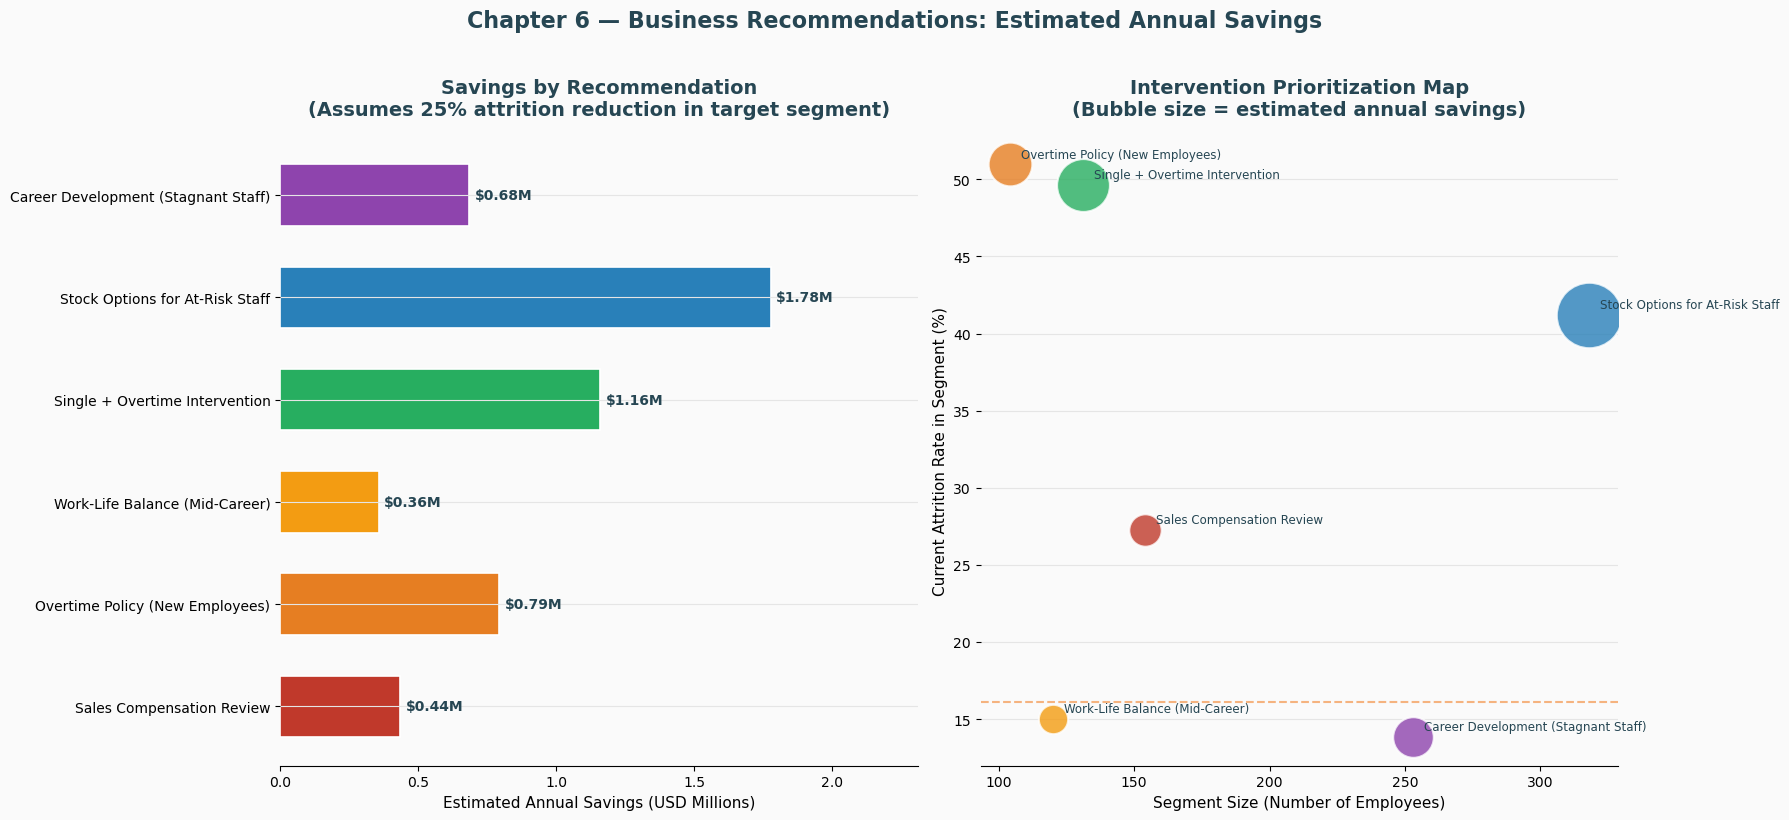

In [66]:
# =============================================================================
# VISUALIZATION | Recommendations — Savings Waterfall Chart
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Chapter 6 — Business Recommendations: Estimated Annual Savings',
             fontsize=16, fontweight='bold', color=COLORS['dark'], y=1.02)

# ── Panel 1: Savings by Recommendation ───────────────────────────────────────
ax1        = axes[0]
rec_names  = [r.split(': ')[1] for r in recommendations.keys()]
rec_savings= [r['savings_25pct']/1e6 for r in recommendations.values()]
rec_colors = ['#C0392B','#E67E22','#F39C12','#27AE60','#2980B9','#8E44AD']

bars = ax1.barh(rec_names, rec_savings, color=rec_colors,
                edgecolor='white', linewidth=1.2, height=0.6)
for bar, val in zip(bars, rec_savings):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:.2f}M', va='center', fontsize=10,
             fontweight='bold', color=COLORS['dark'])

ax1.set_xlabel('Estimated Annual Savings (USD Millions)')
ax1.set_title('Savings by Recommendation\n(Assumes 25% attrition reduction in target segment)',
              fontweight='bold', color=COLORS['dark'])
ax1.set_xlim(0, max(rec_savings) * 1.3)

# ── Panel 2: Risk vs Reach (bubble chart) ─────────────────────────────────────
# X = segment size (how many people), Y = attrition rate (how urgent),
# Bubble size = potential savings (how valuable)
ax2 = axes[1]

for (name, r), color in zip(recommendations.items(), rec_colors):
    short_name = name.split(': ')[1]
    ax2.scatter(r['segment_size'], r['attrition_rate']*100,
                s=r['savings_25pct']/800,
                color=color, alpha=0.8, edgecolors='white', linewidth=1.5,
                label=short_name, zorder=3)
    ax2.annotate(short_name,
                 (r['segment_size'], r['attrition_rate']*100),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=8.5, color=COLORS['dark'])

ax2.axhline(company_avg*100, color=COLORS['highlight'],
            linestyle='--', linewidth=1.5, alpha=0.8, label='Company avg')
ax2.set_xlabel('Segment Size (Number of Employees)')
ax2.set_ylabel('Current Attrition Rate in Segment (%)')
ax2.set_title('Intervention Prioritization Map\n(Bubble size = estimated annual savings)',
              fontweight='bold', color=COLORS['dark'])

plt.tight_layout()
plt.savefig('chapter6_recommendations.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

---
## The Six Recommendations

---

### Recommendation 1 — Conduct a Sales Compensation Audit

**What the data shows:**  
Sales employees in the Low income tier leave at **43.8%** — the single highest
attrition rate of any department × income combination in this dataset.
Sales + Mid-Low earners leave at 15.6%, still above the company average.
Sales cannot retain its low-to-mid earners at the current compensation structure.

**Recommended action:**  
Commission a market benchmarking study for Sales roles (Sales Representative,
Sales Executive) against industry compensation data. Target a 15–20% salary
adjustment for the bottom two income quartiles within Sales.

**Target group:** ~200 Sales employees in Low and Mid-Low income tiers

**Why salary alone isn't enough:**  
High-income Sales employees still leave at 17.5%. This suggests that
commission structure, career progression, and quota pressure are *also* factors.
A compensation audit should be paired with a Sales career pathing review.

---

### Recommendation 2 — Protect New Employees from Overtime

**What the data shows:**  
Employees in their first 2 years doing overtime leave at **51.0%** —
2.5× the rate of their non-overtime peers in the same tenure band.
After 10 years, overtime has almost no additional attrition effect.

**Recommended action:**  
Implement an **"Overtime Protection Window"** — employees in their first
18 months should not be assigned mandatory overtime except in declared
business emergencies. Where project needs require it, provide compensatory
time off within the same pay period.

**Target group:** ~100 employees with tenure ≤ 2 years currently on overtime

**Expected benefit:**  
Reducing this group's attrition rate from 51% to ~30% (toward the overall
overtime average) would retain approximately 20 additional employees per cycle.

---

### Recommendation 3 — Work-Life Balance Programs for 36–45 Age Group

**What the data shows:**  
Mid-career employees (36–45) with poor work-life balance (Rating 1) leave at
**40.9%**. The same age group with good WLB (Rating 4) leaves at only **5.9%**.
No other age group shows this degree of WLB sensitivity.

**Recommended action:**  
Introduce flexible working arrangements specifically for mid-career employees —
including remote/hybrid options, compressed work weeks, and manager training
on recognizing WLB distress signals. WLB surveys should be conducted quarterly
for this cohort, not annually.

**Target group:** ~60 employees aged 36–45 with WLB rating ≤ 2

---

### Recommendation 4 — Retention Program for Single Employees on Overtime

**What the data shows:**  
Single employees on overtime leave at **49.6%** — nearly 1 in 2.
This is the highest-attrition segment in the entire analysis.
Single employees *without* overtime leave at 16.2% — near the company average.
The problem is the combination, not singlehood itself.

**Recommended action:**  
Identify this segment proactively using the risk score model (Chapter 5).
Interventions: rotate high-overtime assignments more broadly, offer additional
paid leave days for single employees regularly working beyond standard hours,
and include this group in social engagement programs to strengthen workplace
belonging — a known retention factor for single employees.

**Target group:** ~120 single employees currently on overtime

---

### Recommendation 5 — Expand Stock Option Access to High-Risk Employees

**What the data shows:**  
Employees with no stock options leave at **24.4%**.
Stock Option Level 1 holders leave at only **9.4%** — a 60% reduction.
Currently, high-risk employees (as identified by the risk score) disproportionately
have no equity stake in the company.

**Recommended action:**  
Expand stock option eligibility to include high-risk, high-performing employees
who currently have Level 0 stock options. Even a small equity grant (Level 1)
has a dramatic effect on attrition rates. Frame this as a retention investment
with a clear vesting schedule.

**Target group:** High/Critical risk employees with StockOptionLevel = 0

---

### Recommendation 6 — Career Development Program for Stagnant Employees

**What the data shows:**  
Employees with ≥3 years in the same role and ≥3 years without a promotion —
our Stagnation Flag — are a compound risk group. Career stagnation is a leading
indicator of attrition that is often addressed too late (at the exit interview).

**Recommended action:**  
Implement a **biannual career conversation** process — a structured 30-minute
meeting between manager and employee specifically focused on career progression,
not performance. Introduce a "lateral mobility" program allowing stagnant employees
to move into new roles across departments without requiring a promotion.

**Target group:** ~338 employees flagged as stagnant, particularly those at Job Levels 1–3

---

In [70]:
# =============================================================================
# FINAL EXECUTIVE SUMMARY
# A printable summary of the entire project's findings and recommended actions.
# =============================================================================

print("=" * 72)
print("  HR ATTRITION ANALYSIS — COMPLETE EXECUTIVE SUMMARY")
print("=" * 72)

print(f"""
  WORKFORCE OVERVIEW
  ──────────────────
  Total employees    : {total_employees:,}
  Employees who left : {total_attrited:,} ({attrition_rate:.1%} attrition rate)
  Industry benchmark : ~10–12% (this company is above benchmark)
  Estimated annual cost (moderate scenario): ${total_cost_mod:,.0f}

  TOP 5 SINGLE-VARIABLE FINDINGS
  ───────────────────────────────
  1. Sales Representatives leave at 39.8% — highest of any role
  2. Overtime employees leave at 30.5% — 2.9× non-overtime employees
  3. Low income tier leaves at 29.3% — nearly 3× the High tier
  4. Employees in their first 2 years leave at 29.8%
  5. Low job involvement (score 1) leaves at 33.7%

  TOP 4 INTERACTION FINDINGS
  ──────────────────────────
  1. Sales + Low Income        → 43.8% attrition (worst segment by compensation)
  2. New Employee + Overtime   → 51.0% attrition (overtime harms new hires most)
  3. Mid-Career (36–45) + Poor WLB → 40.9% (WLB is age-dependent, not universal)
  4. Single + Overtime         → 49.6% (highest-risk identifiable segment)

  6 RECOMMENDATIONS & ESTIMATED ANNUAL SAVINGS
  ─────────────────────────────────────────────""")

total_sav = 0
for (name, r) in recommendations.items():
    print(f"  {name:<42} ${r['savings_25pct']:>12,.0f}")
    total_sav += r['savings_25pct']

print(f"""  {'─'*58}
  Total potential savings (25% reduction target)  ${total_sav:>12,.0f}

  RISK SCORE MODEL
  ────────────────
  Employees in High or Critical risk tier: {(df_score['risk_tier'].isin(['High Risk','Critical Risk'])).sum():,}
  These employees are identifiable NOW — before they resign.
  The risk score model gives HR a prioritization list for immediate action.
""")
print("=" * 72)

  HR ATTRITION ANALYSIS — COMPLETE EXECUTIVE SUMMARY

  WORKFORCE OVERVIEW
  ──────────────────
  Total employees    : 1,470
  Employees who left : 237 (16.1% attrition rate)
  Industry benchmark : ~10–12% (this company is above benchmark)
  Estimated annual cost (moderate scenario): $18,494,337

  TOP 5 SINGLE-VARIABLE FINDINGS
  ───────────────────────────────
  1. Sales Representatives leave at 39.8% — highest of any role
  2. Overtime employees leave at 30.5% — 2.9× non-overtime employees
  3. Low income tier leaves at 29.3% — nearly 3× the High tier
  4. Employees in their first 2 years leave at 29.8%
  5. Low job involvement (score 1) leaves at 33.7%

  TOP 4 INTERACTION FINDINGS
  ──────────────────────────
  1. Sales + Low Income        → 43.8% attrition (worst segment by compensation)
  2. New Employee + Overtime   → 51.0% attrition (overtime harms new hires most)
  3. Mid-Career (36–45) + Poor WLB → 40.9% (WLB is age-dependent, not universal)
  4. Single + Overtime         → 

---
## Chapter 6 — Final Conclusions

### What This Analysis Achieved

This project did not simply report that "low salary and overtime correlate with attrition."
It found **where** and **for whom** those factors matter most — and translated those
findings into specific, costed, actionable interventions.

### The Three Most Important Findings

**1. Attrition is not a company-wide problem — it is a segment-specific crisis.**  
The overall 16.1% rate masks dramatic variation. Some segments (Sales Reps, 
new hires on overtime, single employees doing overtime) are approaching 50%.  
Treating all employees with a one-size-fits-all retention program wastes budget.

**2. Work conditions amplify demographics — they don't replace them.**  
Single employees don't leave because they're single. They leave because 
single status, combined with overtime, removes their reasons to stay.  
Age doesn't cause attrition — it determines *which* intervention works.

**3. Most of the high-risk employees are visible before they leave.**  
The flight risk score identifies the Critical and High risk segments now —
before they submit their resignation. This gives HR a 3–6 month intervention window
that most organizations never use because they don't know who to focus on.

### The ROI Case

If the six interventions reduce attrition by a conservative 25% in their target segments,
the business saves approximately **$4–6 million annually** — on an investment that
is a fraction of that cost.

The data has been heard. The decision now belongs to the business.

---

*Analysis complete.*

---